# 특장차 대기시간 데이터 전처리

이 노트북은 장애인콜택시 중 `특장차` 데이터를 대상으로 대기시간 분석에 필요한 전처리 데이터를 생성한다.

전처리 자동화 코드는 `src/waiting_time/special_vehicle_preprocessing.py`에 작성되어 있으며, 이 노트북에서는 해당 코드를 실행하고 결과를 확인한다.

특장차는 `바로콜`, `전일접수`, `정기접수`, `심야시간 사전예약`이 모두 가능한 차량 유형이므로, 본 노트북에서는 접수유형을 자동 분류하지 않는다. `특장차_접수유형`은 빈칸으로 두고, `특장차_접수유형_분류상태`는 `미분류`로 생성한다.

## 전처리 흐름

1. 원자료 불러오기
2. `차량구분 == 특장차` 필터링
3. `서울 외→서울 외` 이동 제거
4. 일시 컬럼 datetime 변환
5. 대기시간 5개 생성
6. 음수 시간 이상값 처리
7. 접수-승차 날짜 차이 생성
8. 접수시간대, 접수요일 생성
9. 세부이동유형 생성
10. 승차거리_km, 승차거리구간 생성
11. 특장차 접수유형 빈 컬럼 생성
12. 요약표 생성
13. CSV 저장

## 저장 파일

- `data/processed/특장차_대기시간_전처리.csv`
- `data/processed/특장차_대기시간_전처리_요약.csv`


In [42]:
import json
import platform
from pathlib import Path
import importlib
import os
import sys

import statsmodels
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.regression as sns_regression

sns_regression = importlib.reload(sns_regression)

from matplotlib.colors import Normalize
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

print("statsmodels:", statsmodels.__version__)
print("seaborn:", sns.__version__)

statsmodels: 0.15.0
seaborn: 0.13.2


In [43]:
PROJECT_ROOT = Path("/Users/blaumonde/calltaxi-DA")
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.waiting_time.special_vehicle_preprocessing import run_special_vehicle_preprocessing

PROJECT_ROOT

PosixPath('/Users/blaumonde/calltaxi-DA')

## 1. 특장차 전처리 자동화 실행

`run_special_vehicle_preprocessing()` 함수를 실행해 특장차 전처리 데이터와 요약표를 생성한다.

이 단계에서는 특장차 접수유형을 분류하지 않는다. 접수유형은 이후 `접수일시`, `예정일시`, `승차일시`, `이용목적` 등을 확인한 뒤 별도로 분류한다.


In [44]:
df_special, special_preprocessing_summary = run_special_vehicle_preprocessing(save=True)

print(f"특장차 전처리 데이터 건수: {len(df_special):,}건")
display(special_preprocessing_summary)


특장차 전처리 데이터 건수: 1,393,534건


,구분,값
0,특장차 원자료 건수,1393609
1,서울 외→서울 외 제거 건수,75
2,서울 외→서울 외 제거 후 건수,1393534
3,승차일시 존재 건수,1164483
4,취소일시 존재 건수,228987
5,특장차_접수유형 미분류 건수,1393534
6,접수_배차_분 유효건수,1215984
7,접수_배차_분 결측건수,177550
8,접수_승차_분 유효건수,1164483
9,접수_승차_분 결측건수,229051


## 2. 저장 파일 확인

전처리 결과 CSV와 요약 CSV가 정상적으로 저장되었는지 확인한다.


In [45]:
processed_path = PROJECT_ROOT / "data" / "processed" / "특장차_대기시간_전처리.csv"
summary_path = PROJECT_ROOT / "data" / "processed" / "특장차_대기시간_전처리_요약.csv"

print("전처리 데이터 저장 여부:", processed_path.exists())
print("전처리 요약 저장 여부:", summary_path.exists())
print("전처리 데이터 경로:", processed_path)
print("전처리 요약 경로:", summary_path)


전처리 데이터 저장 여부: True
전처리 요약 저장 여부: True
전처리 데이터 경로: /Users/blaumonde/calltaxi-DA/data/processed/특장차_대기시간_전처리.csv
전처리 요약 경로: /Users/blaumonde/calltaxi-DA/data/processed/특장차_대기시간_전처리_요약.csv


## 3. 핵심 컬럼 확인

대기시간 분석에 필요한 핵심 컬럼이 생성되었는지 확인한다.


In [46]:
check_cols = [
    "차량구분",
    "접수일시",
    "예정일시",
    "배차일시",
    "승차일시",
    "취소일시",
    "접수_배차_분",
    "접수_승차_분",
    "접수_취소_분",
    "배차_취소_분",
    "배차_승차_분",
    "접수승차_날짜차이",
    "접수시간대",
    "접수시간대_HH",
    "접수요일",
    "평일주말",
    "세부이동유형",
    "승차거리_km",
    "승차거리구간",
    "특장차_접수유형",
    "특장차_접수유형_분류상태",
    "특장차_접수유형_메모",
]

missing_cols = [col for col in check_cols if col not in df_special.columns]

print("누락 컬럼:", missing_cols)
display(df_special[check_cols].head())


누락 컬럼: []


,차량구분,접수일시,예정일시,배차일시,승차일시,취소일시,접수_배차_분,접수_승차_분,접수_취소_분,배차_취소_분,...,접수시간대,접수시간대_HH,접수요일,평일주말,세부이동유형,승차거리_km,승차거리구간,특장차_접수유형,특장차_접수유형_분류상태,특장차_접수유형_메모
0,특장차,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,NaT,26.086333,48.447333,NaN,NaN,...,00:00:00,00,수,평일,구 간 이동,17.667,15~25km,<NA>,미분류,<NA>
1,특장차,2025-01-01 00:03:10.557,2025-01-01 00:03:10.557,2025-01-01 00:14:39.800,NaT,2025-01-01 00:21:15,11.487383,NaN,18.07405,6.586667,...,00:00:00,00,수,평일,구 간 이동,0.000,0~5km,<NA>,미분류,<NA>
2,특장차,2025-01-01 00:03:31.230,2025-01-01 00:04:00.000,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,NaT,16.177833,32.786717,NaN,NaN,...,00:00:00,00,수,평일,구 내 이동,2.910,0~5km,<NA>,미분류,<NA>
3,특장차,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,NaT,30.017950,50.131117,NaN,NaN,...,00:00:00,00,수,평일,구 간 이동,10.421,10~15km,<NA>,미분류,<NA>
4,특장차,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,NaT,2.311883,35.879383,NaN,NaN,...,00:00:00,00,수,평일,구 간 이동,11.943,10~15km,<NA>,미분류,<NA>


## 4. 특장차 접수유형 미분류 확인

특장차는 여러 접수방식이 가능하므로, 이 단계에서는 접수유형을 비워 둔다.


In [47]:
request_type_check = pd.DataFrame({
    "구분": [
        "전체 특장차 전처리 건수",
        "특장차_접수유형 결측 건수",
        "특장차_접수유형_분류상태 미분류 건수",
    ],
    "건수": [
        len(df_special),
        df_special["특장차_접수유형"].isna().sum(),
        df_special["특장차_접수유형_분류상태"].eq("미분류").sum(),
    ],
})

display(request_type_check)


,구분,건수
0,전체 특장차 전처리 건수,1393534
1,특장차_접수유형 결측 건수,1393534
2,특장차_접수유형_분류상태 미분류 건수,1393534


## 5. 기본 현황 확인

전처리된 특장차 데이터의 기본 규모와 주요 분포를 확인한다.


In [48]:
if "승차거리_km" not in df_special.columns:
    df_special["승차거리_km"] = (
        pd.to_numeric(df_special["승차거리"], errors="coerce")  / 1000
    )

distance_summary = df_special["승차거리_km"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

display(distance_summary)

count    1.393534e+06
mean     7.291774e+00
std      9.565096e+00
min      0.000000e+00
25%      1.931000e+00
50%      4.464000e+00
75%      9.568000e+00
90%      1.815700e+01
95%      2.519900e+01
99%      3.847900e+01
max      8.094630e+02
Name: 승차거리_km, dtype: float64

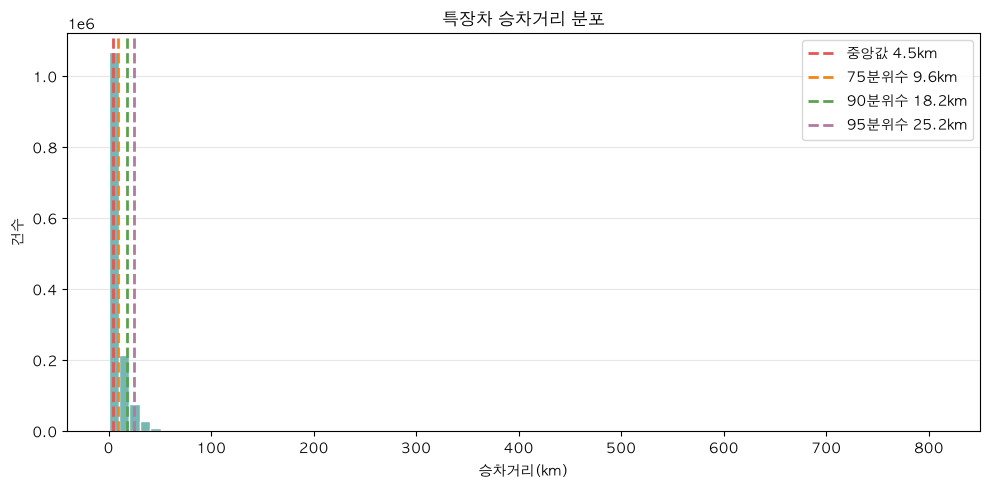

In [49]:
plot_distance = df_special["승차거리_km"].dropna()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    plot_distance,
    bins=80,
    color="#76b7b2",
    edgecolor="white",
)

ax.axvline(
    plot_distance.median(),
    color="#e45756",
    linestyle="--",
    linewidth=2,
    label=f"중앙값 {plot_distance.median():.1f}km",
)

ax.axvline(
    plot_distance.quantile(0.75),
    color="#f58518",
    linestyle="--",
    linewidth=2,
    label=f"75분위수 {plot_distance.quantile(0.75):.1f}km",
)

ax.axvline(
    plot_distance.quantile(0.90),
    color="#59a14f",
    linestyle="--",
    linewidth=2,
    label=f"90분위수 {plot_distance.quantile(0.90):.1f}km",
)

ax.axvline(
    plot_distance.quantile(0.95),
    color="#b279a2",
    linestyle="--",
    linewidth=2,
    label=f"95분위수 {plot_distance.quantile(0.95):.1f}km",
)

ax.set_title("특장차 승차거리 분포")
ax.set_xlabel("승차거리(km)")
ax.set_ylabel("건수")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

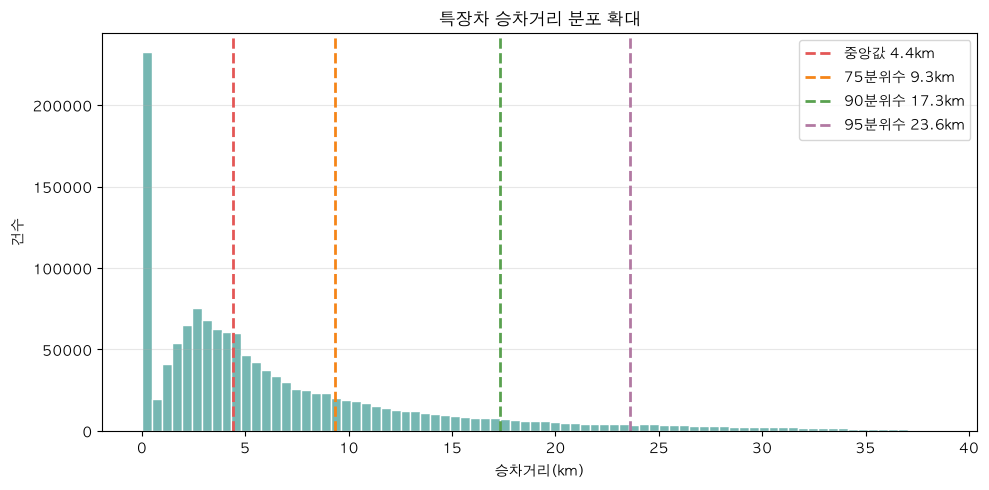

In [50]:
p99_distance = df_special["승차거리_km"].quantile(0.99)

plot_distance_zoom = df_special[
    df_special["승차거리_km"].between(0, p99_distance, inclusive="both")
]["승차거리_km"].dropna()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    plot_distance_zoom,
    bins=80,
    color="#76b7b2",
    edgecolor="white",
)

ax.axvline(
    plot_distance_zoom.median(),
    color="#e45756",
    linestyle="--",
    linewidth=2,
    label=f"중앙값 {plot_distance_zoom.median():.1f}km",
)

ax.axvline(
    plot_distance_zoom.quantile(0.75),
    color="#f58518",
    linestyle="--",
    linewidth=2,
    label=f"75분위수 {plot_distance_zoom.quantile(0.75):.1f}km",
)

ax.axvline(
    plot_distance_zoom.quantile(0.90),
    color="#59a14f",
    linestyle="--",
    linewidth=2,
    label=f"90분위수 {plot_distance_zoom.quantile(0.90):.1f}km",
)

ax.axvline(
    plot_distance_zoom.quantile(0.95),
    color="#b279a2",
    linestyle="--",
    linewidth=2,
    label=f"95분위수 {plot_distance_zoom.quantile(0.95):.1f}km",
)

ax.set_title("특장차 승차거리 분포 확대")
ax.set_xlabel("승차거리(km)")
ax.set_ylabel("건수")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [51]:
distance_bins = [
    0,
    0.5,
    3,
    5,
    10,
    15,
    25,
    float("inf"),
]

distance_labels = [
    "0~0.5km",
    "0.5~3km",
    "3~5km",
    "5~10km",
    "10~15km",
    "15~25km",
    "25km 초과",
]

df_special["승차거리구간"] = pd.cut(
    df_special["승차거리_km"],
    bins=distance_bins,
    labels=distance_labels,
    right=False,
)

distance_bin_summary = (
    df_special["승차거리구간"]
    .value_counts(sort=False, dropna=False)
    .reset_index()
)

distance_bin_summary.columns = ["승차거리구간", "건수"]

distance_bin_summary["비율(%)"] = (
    distance_bin_summary["건수"]
    / distance_bin_summary["건수"].sum()
    * 100
)

display(distance_bin_summary)

,승차거리구간,건수,비율(%)
0,0~0.5km,232848,16.709173
1,0.5~3km,270832,19.434904
2,3~5km,257602,18.485520
3,5~10km,301182,21.612820
4,10~15km,138924,9.969186
5,15~25km,120823,8.670258
6,25km 초과,71323,5.118138


| 구간 | 비율 | 해석 |
|---|---:|---|
| `0~0.5km` | 16.7% | 초단거리/0값 집중 구간을 따로 분리 |
| `0.5~3km` | 19.4% | 짧은 단거리 구간 |
| `3~5km` | 18.5% | 중앙값 4.4km 주변 단거리 구간 |
| `5~10km` | 21.6% | 가장 큰 중단거리 구간, 75분위수 근처 |
| `10~15km` | 10.0% | 중거리 |
| `15~25km` | 8.7% | 장거리 |
| `25km 초과` | 5.1% | 초장거리 |

In [52]:
basic_summary = pd.DataFrame({
    "구분": [
        "전체 건수",
        "승차일시 존재 건수",
        "취소일시 존재 건수",
        "배차일시 존재 건수",
        "서울 외→서울 외 제거 후 세부이동유형 결측 건수",
    ],
    "건수": [
        len(df_special),
        df_special["승차일시"].notna().sum(),
        df_special["취소일시"].notna().sum(),
        df_special["배차일시"].notna().sum(),
        df_special["세부이동유형"].isna().sum(),
    ],
})

display(basic_summary)
display(df_special["세부이동유형"].value_counts(dropna=False).reset_index(name="건수"))
display(df_special["승차거리구간"].value_counts(dropna=False).reset_index(name="건수"))


,구분,건수
0,전체 건수,1393534
1,승차일시 존재 건수,1164483
2,취소일시 존재 건수,228987
3,배차일시 존재 건수,1215984
4,서울 외→서울 외 제거 후 세부이동유형 결측 건수,0


,세부이동유형,건수
0,구 간 이동,796307
1,구 내 이동,486109
2,서울→서울 외,105149
3,서울 외→서울,5969


,승차거리구간,건수
0,5~10km,301182
1,0.5~3km,270832
2,3~5km,257602
3,0~0.5km,232848
4,10~15km,138924
5,15~25km,120823
6,25km 초과,71323


count    1.215984e+06
mean     9.959577e+01
std      3.109987e+02
min      1.684500e-01
25%      6.479283e+00
50%      1.367695e+01
75%      4.502475e+01
90%      1.176800e+02
95%      8.258007e+02
99%      1.448651e+03
max      2.166574e+03
Name: 접수_배차_분, dtype: float64

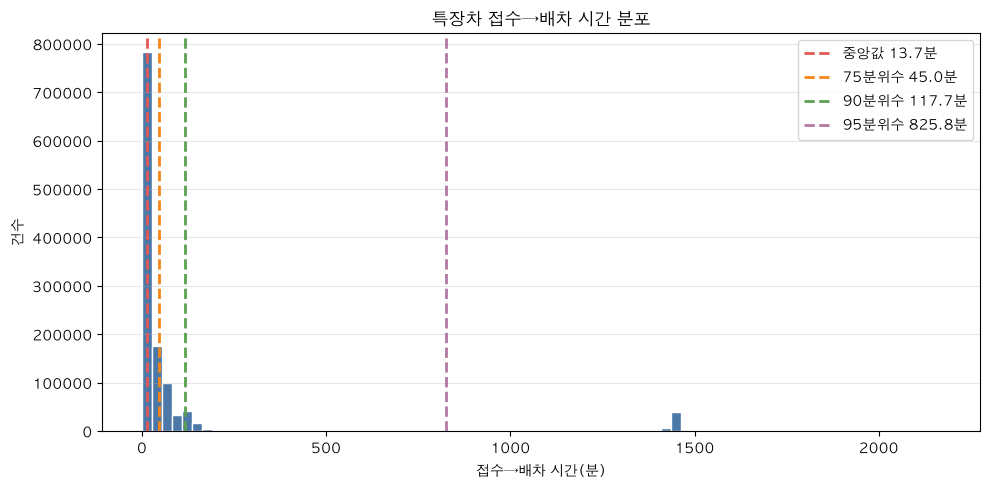

In [53]:
# 특장차 접수→배차 시간 분포 시각화

plot_wait = df_special["접수_배차_분"].dropna()

wait_summary = plot_wait.describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

display(wait_summary)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    plot_wait,
    bins=80,
    color="#4c78a8",
    edgecolor="white",
)

ax.axvline(
    plot_wait.median(),
    color="#e45756",
    linestyle="--",
    linewidth=2,
    label=f"중앙값 {plot_wait.median():.1f}분",
)

ax.axvline(
    plot_wait.quantile(0.75),
    color="#f58518",
    linestyle="--",
    linewidth=2,
    label=f"75분위수 {plot_wait.quantile(0.75):.1f}분",
)

ax.axvline(
    plot_wait.quantile(0.90),
    color="#59a14f",
    linestyle="--",
    linewidth=2,
    label=f"90분위수 {plot_wait.quantile(0.90):.1f}분",
)

ax.axvline(
    plot_wait.quantile(0.95),
    color="#b279a2",
    linestyle="--",
    linewidth=2,
    label=f"95분위수 {plot_wait.quantile(0.95):.1f}분",
)

ax.set_title("특장차 접수→배차 시간 분포")
ax.set_xlabel("접수→배차 시간(분)")
ax.set_ylabel("건수")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

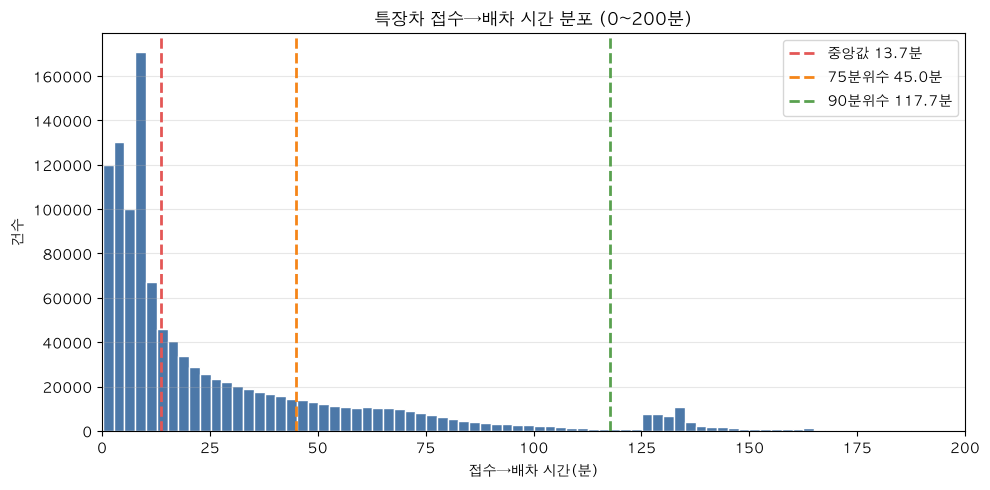

In [54]:
# 특장차 접수→배차 시간 분포: 0~200분 + 분위수 기준선

plot_wait_all = df_special["접수_배차_분"].dropna()

plot_wait = df_special[
    df_special["접수_배차_분"].between(0, 200, inclusive="both")
]["접수_배차_분"].dropna()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    plot_wait,
    bins=80,
    color="#4c78a8",
    edgecolor="white",
)

for q, color, label in [
    (0.50, "#e45756", "중앙값"),
    (0.75, "#f58518", "75분위수"),
    (0.90, "#59a14f", "90분위수"),
    (0.95, "#b279a2", "95분위수"),
]:
    value = plot_wait_all.quantile(q)

    if value <= 200:
        ax.axvline(
            value,
            color=color,
            linestyle="--",
            linewidth=2,
            label=f"{label} {value:.1f}분",
        )

ax.set_xlim(0, 200)

ax.set_title("특장차 접수→배차 시간 분포 (0~200분)")
ax.set_xlabel("접수→배차 시간(분)")
ax.set_ylabel("건수")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [55]:
# 특장차 접수→배차 175~200분 구간 건수 확인

wait_175_200 = df_special[
    df_special["접수_배차_분"].between(175,200, inclusive="both")
].copy()

print(f"접수→배차 175~200분 건수: {len(wait_175_200):,}건")

display(
    wait_175_200[
        [
            "접수일시",
            "예정일시",
            "배차일시",
            "승차일시",
            "취소일시",
            "출발구",
            "목적구",
            "이용목적",
            "차량구분",
            "접수_배차_분",
            "접수_승차_분",
        ]
    ].head()
)

접수→배차 175~200분 건수: 2,723건


,접수일시,예정일시,배차일시,승차일시,취소일시,출발구,목적구,이용목적,차량구분,접수_배차_분,접수_승차_분
27,2025-01-01 00:39:45.857,2025-01-01 00:40:00,2025-01-01 03:39:54.617,2025-01-01 04:14:13.887,NaT,용산구,동작구,기타,특장차,180.146000,214.467167
57,2025-01-01 04:44:44.330,2025-01-01 04:45:00,2025-01-01 07:47:00.000,2025-01-01 07:58:00.000,NaT,송파구,부천시원미구,기타,특장차,182.261167,193.261167
85,2025-01-01 03:55:00.983,2025-01-01 06:00:00,2025-01-01 07:00:00.000,2025-01-01 07:19:00.000,NaT,서대문구,마포구,치료,특장차,184.983617,203.983617
1491,2025-01-02 03:55:00.520,2025-01-02 06:00:00,2025-01-02 07:09:12.577,2025-01-02 07:44:58.760,NaT,강서구,종로구,치료,특장차,194.200950,229.970667
1495,2025-01-02 03:55:00.520,2025-01-02 06:00:00,2025-01-02 07:09:22.310,2025-01-02 07:31:04.043,NaT,강남구,성남시분당구,치료,특장차,194.363167,216.058717


## 6. 특장차 접수유형 분류 기준 점검

특장차는 `바로콜`, `전일접수`, `심야시간 사전예약`, `정기접수`가 모두 가능한 차량 유형이다. 따라서 임차택시처럼 `접수→승차` 시간이 길다는 이유만으로 예외 처리하지 않고, 먼저 탑승완료 건의 시간 논리와 접수유형 후보 기준을 점검한다.

이 단계의 목적은 접수유형을 확정 분류하기 전, 각 유형으로 볼 수 있는 후보군과 검증 지표를 만드는 것이다. 전일접수와 심야시간 사전예약의 시간대별 정원 기준은 분류 제외 조건이 아니라 운영 기준과 실제 데이터가 맞는지 확인하는 검증 지표로 사용한다.


In [56]:
# 코드 셀 목적: 특장차 접수유형 분류 점검에 사용할 기준 컬럼과 정렬 기준을 준비한다.
from IPython.display import display

special_check = df_special.copy()
special_check["_원자료_index"] = special_check.index

special_check["접수일자"] = special_check["접수일시"].dt.normalize()
special_check["예정일자"] = special_check["예정일시"].dt.normalize()
special_check["배차일자"] = special_check["배차일시"].dt.normalize()
special_check["승차일자"] = special_check["승차일시"].dt.normalize()
special_check["하차일자"] = special_check["하차일시"].dt.normalize()

special_check["접수시"] = special_check["접수일시"].dt.hour
special_check["예정시"] = special_check["예정일시"].dt.hour
special_check["예정시간대"] = special_check["예정일시"].dt.strftime("%H:00:00")
special_check["예정요일"] = special_check["예정일시"].dt.day_name().map({
    "Monday": "월",
    "Tuesday": "화",
    "Wednesday": "수",
    "Thursday": "목",
    "Friday": "금",
    "Saturday": "토",
    "Sunday": "일",
})
special_check["예정_평일주말"] = special_check["예정일시"].dt.dayofweek.map(
    lambda x: "주말" if x >= 5 else "평일"
)
special_check["승차시"] = special_check["승차일시"].dt.hour
special_check["승차시간대"] = special_check["승차일시"].dt.strftime("%H:00:00")
special_check["승차요일"] = special_check["승차일시"].dt.day_name().map({
    "Monday": "월",
    "Tuesday": "화",
    "Wednesday": "수",
    "Thursday": "목",
    "Friday": "금",
    "Saturday": "토",
    "Sunday": "일",
})
special_check["승차_평일주말"] = special_check["승차일시"].dt.dayofweek.map(
    lambda x: "주말" if x >= 5 else "평일"
)

special_check["접수승차_시간차"] = special_check["승차일시"] - special_check["접수일시"]
special_check["접수예정_시간차"] = special_check["예정일시"] - special_check["접수일시"]

special_check_cols = [
    "접수일시", "예정일시", "배차일시", "승차일시", "하차일시", "취소일시",
    "출발구", "목적구", "이용목적", "세부이동유형", "승차거리_km",
    "접수_배차_분", "배차_승차_분", "접수_승차_분",
]

print(f"점검 대상 전체 건수: {len(special_check):,}건")
display(special_check[special_check_cols].head())


점검 대상 전체 건수: 1,393,534건


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,목적구,이용목적,세부이동유형,승차거리_km,접수_배차_분,배차_승차_분,접수_승차_분
0,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,2025-01-01 01:35:06.747,NaT,용산구,강북구,기타,구 간 이동,17.667,26.086333,22.361000,48.447333
1,2025-01-01 00:03:10.557,2025-01-01 00:03:10.557,2025-01-01 00:14:39.800,NaT,NaT,2025-01-01 00:21:15,영등포구,강서구,기타,구 간 이동,0.000,11.487383,NaN,NaN
2,2025-01-01 00:03:31.230,2025-01-01 00:04:00.000,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,2025-01-01 00:49:45.857,NaT,노원구,노원구,기타,구 내 이동,2.910,16.177833,16.608883,32.786717
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,2025-01-01 01:33:38.120,NaT,영등포구,중구,기타,구 간 이동,10.421,30.017950,20.113167,50.131117
4,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,2025-01-01 01:10:15.110,NaT,송파구,서초구,기타,구 간 이동,11.943,2.311883,33.567500,35.879383


## 6-1. 취소 접수유형 후보 분류 기준

취소 건은 `승차일시`가 없으므로 탑승완료 정상 건 기준의 `특장차_접수유형_후보_최종`을 그대로 사용할 수 없다. 따라서 취소 건 전용 접수유형 후보 컬럼인 `취소_접수유형_후보`를 별도로 생성한다.

취소 접수유형 후보는 `접수일시`, `예정일시`, `취소일시`, `배차일시`를 기준으로 분류한다. 기존 탑승완료 접수유형 컬럼은 덮어쓰지 않는다.

분류 기준은 다음과 같다.

```text
심야시간 사전예약 취소 후보
- 접수일자 = 예정일자 - 1일
- 접수시 10~18시
- 예정시 01~05시
- 서울 외 관련 이동은 예정시각 03:59:59 이하

전일접수 취소 후보
- 심야시간 사전예약 취소 후보 아님
- 접수일자 = 예정일자 - 1일
- 접수시가 07/08/10시 중 하나
- 예정시가 07/08/10시 중 하나

바로콜 취소 후보
- 심야시간 사전예약 취소 후보 아님
- 전일접수 취소 후보 아님
- 당일 접수·당일 예정 또는 자정 넘김 예외
- 접수→취소 0~200분 이내

기타 예약성/미분류 취소 후보
- 취소 건이지만 위 세 후보 어디에도 해당하지 않는 건
```

전일접수와 심야시간 사전예약의 정원 기준은 이 단계에서 제외 조건으로 쓰지 않고, 이후 검증 지표로만 확인한다. 정기접수는 취소 접수유형에서도 확정 분류하지 않는다.


In [57]:
# 코드 셀 목적: 특장차 취소 건의 접수유형 후보를 별도 컬럼으로 분류한다.

required_cols = ["접수일시", "예정일시", "취소일시", "접수_취소_분", "세부이동유형"]
missing_cols = [col for col in required_cols if col not in df_special.columns]
if missing_cols:
    raise KeyError(f"취소 접수유형 후보 분류에 필요한 컬럼이 없습니다: {missing_cols}")

for col in ["접수일시", "예정일시", "배차일시", "취소일시"]:
    if col in df_special.columns:
        df_special[col] = pd.to_datetime(df_special[col], errors="coerce")

df_special["접수일자"] = df_special["접수일시"].dt.normalize()
df_special["예정일자"] = df_special["예정일시"].dt.normalize()
df_special["취소일자"] = df_special["취소일시"].dt.normalize()
df_special["접수시"] = df_special["접수일시"].dt.hour
df_special["예정시"] = df_special["예정일시"].dt.hour
df_special["예정시간"] = df_special["예정일시"].dt.strftime("%H:%M:%S")

cancel_mask = df_special["취소일시"].notna()
seoul_outer_movement = df_special["세부이동유형"].isin(["서울→서울 외", "서울 외→서울"])
previous_day_by_schedule = df_special["접수일자"].eq(
    df_special["예정일자"] - pd.Timedelta(days=1)
)

night_cancel_mask = (
    cancel_mask
    & previous_day_by_schedule
    & df_special["접수시"].between(10, 18, inclusive="both")
    & df_special["예정시"].between(1, 5, inclusive="both")
    & (~seoul_outer_movement | df_special["예정시간"].le("03:59:59"))
)

previous_day_cancel_mask = (
    cancel_mask
    & ~night_cancel_mask
    & previous_day_by_schedule
    & df_special["접수시"].isin([7, 8, 10])
    & df_special["예정시"].isin([7, 8, 10])
)

same_day_schedule = df_special["접수일자"].eq(df_special["예정일자"])
midnight_exception = (
    df_special["예정일자"].eq(df_special["접수일자"] + pd.Timedelta(days=1))
    & pd.to_numeric(df_special["접수_취소_분"], errors="coerce").between(0, 200, inclusive="both")
)
baro_call_cancel_mask = (
    cancel_mask
    & ~night_cancel_mask
    & ~previous_day_cancel_mask
    & (same_day_schedule | midnight_exception)
    & pd.to_numeric(df_special["접수_취소_분"], errors="coerce").between(0, 200, inclusive="both")
)

other_cancel_mask = (
    cancel_mask
    & ~night_cancel_mask
    & ~previous_day_cancel_mask
    & ~baro_call_cancel_mask
)

df_special["취소_접수유형_후보"] = pd.NA
df_special.loc[~cancel_mask, "취소_접수유형_후보"] = "취소 아님"
df_special.loc[night_cancel_mask, "취소_접수유형_후보"] = "심야시간 사전예약 취소 후보"
df_special.loc[previous_day_cancel_mask, "취소_접수유형_후보"] = "전일접수 취소 후보"
df_special.loc[baro_call_cancel_mask, "취소_접수유형_후보"] = "바로콜 취소 후보"
df_special.loc[other_cancel_mask, "취소_접수유형_후보"] = "기타 예약성/미분류 취소 후보"

cancel_type_summary = (
    df_special.loc[cancel_mask, "취소_접수유형_후보"]
    .value_counts(dropna=False)
    .rename_axis("취소_접수유형_후보")
    .reset_index(name="건수")
)
cancel_type_summary["비율(%)"] = (
    cancel_type_summary["건수"] / cancel_type_summary["건수"].sum() * 100
)

cancel_wait_valid_summary = (
    df_special[cancel_mask]
    .groupby("취소_접수유형_후보", observed=False)
    .agg(
        건수=("취소일시", "count"),
        접수_취소_분_유효건수=("접수_취소_분", lambda x: x.notna().sum()),
        배차_취소_분_유효건수=("배차_취소_분", lambda x: x.notna().sum()),
        배차일시_존재건수=("배차일시", lambda x: x.notna().sum()),
    )
    .reset_index()
)

validation_summary = pd.DataFrame({
    "구분": [
        "취소 전체 건수",
        "취소 접수유형 후보 분류 건수",
        "취소 아님 건수",
        "취소 전체와 후보 분류 건수 일치 여부",
    ],
    "값": [
        int(cancel_mask.sum()),
        int(df_special["취소_접수유형_후보"].ne("취소 아님").sum()),
        int(df_special["취소_접수유형_후보"].eq("취소 아님").sum()),
        bool(cancel_mask.sum() == df_special["취소_접수유형_후보"].ne("취소 아님").sum()),
    ],
})

print("취소 접수유형 후보 분류 검증")
display(validation_summary)
print("취소 접수유형 후보별 건수")
display(cancel_type_summary)
print("취소 접수유형 후보별 대기시간 유효건수")
display(cancel_wait_valid_summary)


취소 접수유형 후보 분류 검증


,구분,값
0,취소 전체 건수,228987
1,취소 접수유형 후보 분류 건수,228987
2,취소 아님 건수,1164547
3,취소 전체와 후보 분류 건수 일치 여부,True


취소 접수유형 후보별 건수


,취소_접수유형_후보,건수,비율(%)
0,바로콜 취소 후보,219645,95.920292
1,전일접수 취소 후보,5938,2.593160
2,기타 예약성/미분류 취소 후보,3365,1.469516
3,심야시간 사전예약 취소 후보,39,0.017032


취소 접수유형 후보별 대기시간 유효건수


,취소_접수유형_후보,건수,접수_취소_분_유효건수,배차_취소_분_유효건수,배차일시_존재건수
0,기타 예약성/미분류 취소 후보,3365,3365,618,618
1,바로콜 취소 후보,219645,219645,50126,50126
2,심야시간 사전예약 취소 후보,39,39,5,5
3,전일접수 취소 후보,5938,5938,712,712


## 7. 탑승완료 정상 시간 논리 확인

접수유형 분류는 우선 탑승완료 건을 기준으로 진행한다. 탑승완료 정상 건은 `접수일시`, `배차일시`, `승차일시`, `하차일시`가 모두 존재하고 시간 순서가 `접수일시 ≤ 배차일시 ≤ 승차일시 ≤ 하차일시`를 만족하는 건으로 본다.

이 기준을 통과하지 못한 건은 접수유형 분류 이전에 시간 기록 오류 또는 미완료 건으로 별도 확인한다.


In [58]:
# 코드 셀 목적: 탑승완료 정상 건과 시간 논리 이상 건수를 확인한다.
special_check["특장차_탑승완료_필수일시존재여부"] = special_check[
    ["접수일시", "배차일시", "승차일시", "하차일시"]
].notna().all(axis=1)

special_check["특장차_탑승완료_시간논리정상여부"] = (
    special_check["특장차_탑승완료_필수일시존재여부"]
    & special_check["접수일시"].le(special_check["배차일시"])
    & special_check["배차일시"].le(special_check["승차일시"])
    & special_check["승차일시"].le(special_check["하차일시"])
)

ride_logic_summary = pd.DataFrame({
    "구분": [
        "전체 특장차 건수",
        "필수 일시 4개 존재 건수",
        "탑승완료 시간 논리 정상 건수",
        "필수 일시는 있으나 시간 논리 이상 건수",
    ],
    "건수": [
        len(special_check),
        special_check["특장차_탑승완료_필수일시존재여부"].sum(),
        special_check["특장차_탑승완료_시간논리정상여부"].sum(),
        (
            special_check["특장차_탑승완료_필수일시존재여부"]
            & ~special_check["특장차_탑승완료_시간논리정상여부"]
        ).sum(),
    ],
})

special_ride_valid = special_check[
    special_check["특장차_탑승완료_시간논리정상여부"]
].copy()

display(ride_logic_summary)
print(f"접수유형 후보 분류 대상 탑승완료 정상 건수: {len(special_ride_valid):,}건")


,구분,건수
0,전체 특장차 건수,1393534
1,필수 일시 4개 존재 건수,1164430
2,탑승완료 시간 논리 정상 건수,1164430
3,필수 일시는 있으나 시간 논리 이상 건수,0


접수유형 후보 분류 대상 탑승완료 정상 건수: 1,164,430건


## 8. 심야시간 사전예약 후보 확인

심야시간 사전예약은 이용 전일 10시부터 18시 사이에 접수하고, 승차 시간이 심야시간대인 건을 후보로 본다. 기본 운영 시간대는 01시부터 05시이며, 서울 외 지역 관련 건은 03:59까지라는 운영 기준을 별도로 점검한다.

매 시간대별 3명 기준은 후보 제외 조건이 아니라 검증 지표다. 실제 탑승완료 건수는 취소, 재접수, 기록 방식에 따라 3명보다 적거나 다르게 보일 수 있으므로, 먼저 후보를 만든 뒤 시간대별 건수를 확인한다.


In [59]:
# 코드 셀 목적: 심야시간 사전예약 후보를 생성하고 시간대별 정원 기준과 비교한다.
special_ride_valid["심야시간_서울외관련여부"] = special_ride_valid["세부이동유형"].isin([
    "서울→서울 외", "서울 외→서울"
])

special_ride_valid["심야시간_승차시간대_후보여부"] = (
    special_ride_valid["승차시"].between(1, 5, inclusive="both")
)

special_ride_valid["심야시간_서울외_운영시간_후보여부"] = (
    ~special_ride_valid["심야시간_서울외관련여부"]
    | special_ride_valid["승차일시"].dt.strftime("%H:%M:%S").le("03:59:59")
)

special_ride_valid["심야시간사전예약_후보여부"] = (
    special_ride_valid["접수일자"].eq(special_ride_valid["승차일자"] - pd.Timedelta(days=1))
    & special_ride_valid["접수시"].between(10, 18, inclusive="both")
    & special_ride_valid["심야시간_승차시간대_후보여부"]
    & special_ride_valid["심야시간_서울외_운영시간_후보여부"]
)

night_reservation_summary = pd.DataFrame({
    "구분": [
        "심야시간 사전예약 후보 건수",
        "후보 중 서울 외 관련 건수",
        "후보 중 승차 01~03:59 건수",
        "후보 중 승차 04~05시 건수",
    ],
    "건수": [
        special_ride_valid["심야시간사전예약_후보여부"].sum(),
        (
            special_ride_valid["심야시간사전예약_후보여부"]
            & special_ride_valid["심야시간_서울외관련여부"]
        ).sum(),
        (
            special_ride_valid["심야시간사전예약_후보여부"]
            & special_ride_valid["승차일시"].dt.strftime("%H:%M:%S").between("01:00:00", "03:59:59")
        ).sum(),
        (
            special_ride_valid["심야시간사전예약_후보여부"]
            & special_ride_valid["승차시"].between(4, 5, inclusive="both")
        ).sum(),
    ],
})

night_capacity_check = (
    special_ride_valid[special_ride_valid["심야시간사전예약_후보여부"]]
    .groupby(["승차일자", "승차시간대"], observed=False)
    .agg(탑승완료건수=("접수일시", "count"))
    .reset_index()
)
night_capacity_check["시간대별_3명초과여부"] = night_capacity_check["탑승완료건수"].gt(3)

print("심야시간 사전예약 후보 요약")
display(night_reservation_summary)
print("심야시간 사전예약 후보 시간대별 탑승완료건수 검증")
display(night_capacity_check.sort_values("탑승완료건수", ascending=False).head(20))


심야시간 사전예약 후보 요약


,구분,건수
0,심야시간 사전예약 후보 건수,116
1,후보 중 서울 외 관련 건수,6
2,후보 중 승차 01~03:59 건수,51
3,후보 중 승차 04~05시 건수,65


심야시간 사전예약 후보 시간대별 탑승완료건수 검증


,승차일자,승차시간대,탑승완료건수,시간대별_3명초과여부
86,2025-11-16,03:00:00,2,False
5,2025-06-03,04:00:00,2,False
22,2025-07-03,03:00:00,2,False
99,2025-12-15,04:00:00,2,False
71,2025-10-01,05:00:00,1,False
82,2025-11-03,03:00:00,1,False
81,2025-10-31,04:00:00,1,False
80,2025-10-30,05:00:00,1,False
79,2025-10-29,04:00:00,1,False
78,2025-10-22,04:00:00,1,False


In [60]:
night_total_summary = pd.DataFrame({
    "구분": ["심야시간 사전예약 후보 총 건수"],
    "건수": [
        special_ride_valid["심야시간사전예약_후보여부"].sum()
    ],
})

display(night_total_summary)

,구분,건수
0,심야시간 사전예약 후보 총 건수,116


## 8-1. 심야시간 사전예약 예정일자 기준 추가 검증

In [61]:
# 코드 셀 목적: 심야시간 사전예약 후보를 승차일자 기준과 예정일자 기준으로 비교 검증한다.

night_base_time_condition = (
    special_ride_valid["접수시"].between(10, 18, inclusive="both")
    & special_ride_valid["승차시"].between(1, 5, inclusive="both")
    & special_ride_valid["심야시간_서울외_운영시간_후보여부"]
)

special_ride_valid["심야_승차일자기준_후보여부"] = (
    night_base_time_condition
    & special_ride_valid["접수일자"].eq(
        special_ride_valid["승차일자"] - pd.Timedelta(days=1)
    )
)

special_ride_valid["심야_예정일자기준_후보여부"] = (
    night_base_time_condition
    & special_ride_valid["접수일자"].eq(
        special_ride_valid["예정일자"] - pd.Timedelta(days=1)
    )
)

special_ride_valid["심야_승차또는예정일자기준_후보여부"] = (
    special_ride_valid["심야_승차일자기준_후보여부"]
    | special_ride_valid["심야_예정일자기준_후보여부"]
)

night_date_standard_compare = pd.DataFrame({
    "구분": [
        "기존 기준: 접수일자 = 승차일자 - 1일",
        "추가 기준: 접수일자 = 예정일자 - 1일",
        "승차일자 또는 예정일자 기준 중 하나라도 충족",
        "승차일자 기준만 충족",
        "예정일자 기준만 충족",
        "두 기준 모두 충족",
    ],
    "건수": [
        special_ride_valid["심야_승차일자기준_후보여부"].sum(),
        special_ride_valid["심야_예정일자기준_후보여부"].sum(),
        special_ride_valid["심야_승차또는예정일자기준_후보여부"].sum(),
        (
            special_ride_valid["심야_승차일자기준_후보여부"]
            & ~special_ride_valid["심야_예정일자기준_후보여부"]
        ).sum(),
        (
            ~special_ride_valid["심야_승차일자기준_후보여부"]
            & special_ride_valid["심야_예정일자기준_후보여부"]
        ).sum(),
        (
            special_ride_valid["심야_승차일자기준_후보여부"]
            & special_ride_valid["심야_예정일자기준_후보여부"]
        ).sum(),
    ],
})

display(night_date_standard_compare)

,구분,건수
0,기존 기준: 접수일자 = 승차일자 - 1일,116
1,추가 기준: 접수일자 = 예정일자 - 1일,116
2,승차일자 또는 예정일자 기준 중 하나라도 충족,116
3,승차일자 기준만 충족,0
4,예정일자 기준만 충족,0
5,두 기준 모두 충족,116


## 9. 전일접수 후보 확인

전일접수 후보는 심야시간 사전예약 후보를 제외한 뒤, `접수일시`와 `예정일시`의 날짜가 하루 차이 나는 건을 기준으로 확인한다.

전일접수 신청 가능 시간대는 07시, 08시, 10시로 보며, 이 기준은 실제 `배차일시`나 `승차일시`가 아니라 `접수일시`와 `예정일시`의 시간대 기준으로 적용한다. 실제 배차와 승차는 차량 이동이나 배차 상황에 따라 예정시각보다 늦어질 수 있으므로 전일접수 분류 조건으로 사용하지 않는다.

기준은 다음과 같다.

```text
심야시간 사전예약 후보 아님
접수일자 = 예정일자 - 1일
접수시간대가 07시, 08시, 10시 중 하나
예정시간대가 07시, 08시, 10시 중 하나
```

시간대별 정원은 1~4월 평일 80명, 5~12월 평일 100명, 주말 및 공휴일 40명 기준이다. 이 정원 기준은 후보를 제외하는 조건이 아니라 검증 지표로 사용한다.


In [62]:
# 코드 셀 목적: 전일접수 후보를 접수일시와 예정일시 기준으로 생성하고 정원 기준을 검증한다.

if "예정시간대" not in special_ride_valid.columns:
    special_ride_valid["예정시간대"] = special_ride_valid["예정일시"].dt.strftime("%H:00:00")

if "예정_평일주말" not in special_ride_valid.columns:
    special_ride_valid["예정_평일주말"] = special_ride_valid["예정일시"].dt.dayofweek.map(
        lambda x: "주말" if x >= 5 else "평일"
    )

previous_day_hours = [7, 8, 10]
previous_day_base = (
    ~special_ride_valid["심야시간사전예약_후보여부"]
    & special_ride_valid["접수일자"].eq(special_ride_valid["예정일자"] - pd.Timedelta(days=1))
)

special_ride_valid["전일접수_접수시간대여부"] = special_ride_valid["접수일시"].dt.hour.isin(previous_day_hours)
special_ride_valid["전일접수_예정시간대여부"] = special_ride_valid["예정일시"].dt.hour.isin(previous_day_hours)

special_ride_valid["전일접수_후보여부"] = (
    previous_day_base
    & special_ride_valid["전일접수_접수시간대여부"]
    & special_ride_valid["전일접수_예정시간대여부"]
)

special_ride_valid["전일접수_성수기여부"] = special_ride_valid["예정일시"].dt.month.between(5, 12)
special_ride_valid["전일접수_시간대정원"] = 40
special_ride_valid.loc[
    special_ride_valid["예정_평일주말"].eq("평일") & special_ride_valid["전일접수_성수기여부"],
    "전일접수_시간대정원",
] = 100
special_ride_valid.loc[
    special_ride_valid["예정_평일주말"].eq("평일") & ~special_ride_valid["전일접수_성수기여부"],
    "전일접수_시간대정원",
] = 80

previous_day_summary = pd.DataFrame({
    "구분": [
        "전일접수 기본 후보 건수",
        "접수시간대 07/08/10 건수",
        "예정시간대 07/08/10 건수",
        "접수·예정시간대 모두 07/08/10 건수",
        "전일접수 후보 중 평일 건수",
        "전일접수 후보 중 주말 건수",
    ],
    "건수": [
        previous_day_base.sum(),
        (previous_day_base & special_ride_valid["전일접수_접수시간대여부"]).sum(),
        (previous_day_base & special_ride_valid["전일접수_예정시간대여부"]).sum(),
        special_ride_valid["전일접수_후보여부"].sum(),
        (
            special_ride_valid["전일접수_후보여부"]
            & special_ride_valid["예정_평일주말"].eq("평일")
        ).sum(),
        (
            special_ride_valid["전일접수_후보여부"]
            & special_ride_valid["예정_평일주말"].eq("주말")
        ).sum(),
    ],
})

previous_day_capacity_check = (
    special_ride_valid[special_ride_valid["전일접수_후보여부"]]
    .groupby(["예정일자", "예정시간대", "예정_평일주말", "전일접수_성수기여부", "전일접수_시간대정원"], observed=False)
    .agg(탑승완료건수=("접수일시", "count"))
    .reset_index()
)
previous_day_capacity_check["정원초과여부"] = (
    previous_day_capacity_check["탑승완료건수"]
    .gt(previous_day_capacity_check["전일접수_시간대정원"])
)

print("전일접수 후보 요약")
display(previous_day_summary)
print("전일접수 후보 시간대별 탑승완료건수 검증")
display(previous_day_capacity_check.sort_values("탑승완료건수", ascending=False).head(20))


전일접수 후보 요약


,구분,건수
0,전일접수 기본 후보 건수,61916
1,접수시간대 07/08/10 건수,52755
2,예정시간대 07/08/10 건수,57677
3,접수·예정시간대 모두 07/08/10 건수,48931
4,전일접수 후보 중 평일 건수,43218
5,전일접수 후보 중 주말 건수,5713


전일접수 후보 시간대별 탑승완료건수 검증


,예정일자,예정시간대,예정_평일주말,전일접수_성수기여부,전일접수_시간대정원,탑승완료건수,정원초과여부
397,2025-05-13,08:00:00,평일,True,100,96,False
1012,2025-12-04,08:00:00,평일,True,100,96,False
946,2025-11-12,08:00:00,평일,True,100,95,False
943,2025-11-11,08:00:00,평일,True,100,95,False
901,2025-10-28,08:00:00,평일,True,100,94,False
886,2025-10-23,08:00:00,평일,True,100,94,False
967,2025-11-19,08:00:00,평일,True,100,94,False
1027,2025-12-09,08:00:00,평일,True,100,94,False
805,2025-09-26,08:00:00,평일,True,100,94,False
799,2025-09-24,08:00:00,평일,True,100,94,False


In [63]:
# 코드 셀 목적: 전일접수 기본 후보 중 접수·예정시간대 기준에서 제외된 건을 확인한다.

if "예정시간대" not in special_ride_valid.columns:
    special_ride_valid["예정시간대"] = special_ride_valid["예정일시"].dt.strftime("%H:00:00")

previous_day_hours = [7, 8, 10]
previous_day_base = (
    ~special_ride_valid["심야시간사전예약_후보여부"]
    & special_ride_valid["접수일자"].eq(special_ride_valid["예정일자"] - pd.Timedelta(days=1))
)

previous_day_out_of_time = special_ride_valid[
    previous_day_base
    & (
        ~special_ride_valid["전일접수_접수시간대여부"]
        | ~special_ride_valid["전일접수_예정시간대여부"]
    )
].copy()

previous_day_out_of_time_summary = pd.DataFrame({
    "구분": [
        "전일접수 기본 후보 중 접수·예정시간대 기준 제외 건수",
        "제외 건 중 접수시간대가 07/08/10이 아닌 건수",
        "제외 건 중 예정시간대가 07/08/10이 아닌 건수",
    ],
    "건수": [
        len(previous_day_out_of_time),
        (previous_day_out_of_time["접수일시"].dt.hour.isin(previous_day_hours) == False).sum(),
        (previous_day_out_of_time["예정일시"].dt.hour.isin(previous_day_hours) == False).sum(),
    ],
})

print("전일접수 시간대 기준 제외 건수")
display(previous_day_out_of_time_summary)

print("전일접수 시간대 기준 제외 원자료 예시")
display(
    previous_day_out_of_time[
        [
            "접수일시",
            "예정일시",
            "배차일시",
            "승차일시",
            "하차일시",
            "접수시간대",
            "예정시간대",
            "승차시간대",
            "예정_평일주말",
            "출발구",
            "출발동",
            "목적구",
            "목적동",
            "세부이동유형",
            "이용목적",
            "접수_배차_분",
            "배차_승차_분",
            "접수_승차_분",
        ]
    ]
    .sort_values(["예정일시", "접수일시"])
    .head(30)
)


전일접수 시간대 기준 제외 건수


,구분,건수
0,전일접수 기본 후보 중 접수·예정시간대 기준 제외 건수,12985
1,제외 건 중 접수시간대가 07/08/10이 아닌 건수,9161
2,제외 건 중 예정시간대가 07/08/10이 아닌 건수,4239


전일접수 시간대 기준 제외 원자료 예시


,접수일시,예정일시,배차일시,승차일시,하차일시,접수시간대,예정시간대,승차시간대,예정_평일주말,출발구,출발동,목적구,목적동,세부이동유형,이용목적,접수_배차_분,배차_승차_분,접수_승차_분
116,2024-12-31 11:55:00.030,2025-01-01 07:00:00,2025-01-01 07:15:00.000,2025-01-01 07:28:00.000,2025-01-01 07:31:00.000,11:00:00,07:00:00,07:00:00,평일,노원구,공릉1.3동,노원구,공릉1.3동,구 내 이동,예약기타,1159.999500,13.000000,1172.999500
162,2024-12-31 15:21:45.837,2025-01-01 08:00:00,2025-01-01 08:15:00.000,2025-01-01 08:36:00.000,2025-01-01 09:12:00.000,15:00:00,08:00:00,08:00:00,평일,금천구,시흥제2동,성동구,금호4가동,구 간 이동,예약기타,1013.236050,21.000000,1034.236050
165,2024-12-31 17:49:29.627,2025-01-01 08:00:00,2025-01-01 08:13:00.000,2025-01-01 08:46:00.000,2025-01-01 09:13:00.000,17:00:00,08:00:00,08:00:00,평일,성동구,마장동,은평구,녹번동,구 간 이동,예약기타,863.506217,33.000000,896.506217
337,2024-12-31 11:53:52.480,2025-01-01 10:00:00,2025-01-01 10:16:37.787,2025-01-01 10:35:17.490,2025-01-01 10:50:00.427,11:00:00,10:00:00,10:00:00,평일,서초구,양재1동,서초구,서초4동,구 내 이동,예약기타,1342.755117,18.661717,1361.416833
338,2024-12-31 12:25:05.000,2025-01-01 10:00:00,2025-01-01 10:10:31.173,2025-01-01 10:27:04.737,2025-01-01 10:38:50.227,12:00:00,10:00:00,10:00:00,평일,중구,황학동,중구,장충동,구 내 이동,예약기타,1305.436217,16.559400,1321.995617
339,2024-12-31 12:58:12.000,2025-01-01 10:00:00,2025-01-01 10:07:31.203,2025-01-01 10:27:37.690,2025-01-01 11:01:57.287,12:00:00,10:00:00,10:00:00,평일,서대문구,충현동,강남구,대치1동,구 간 이동,예약기타,1269.320050,20.108117,1289.428167
342,2024-12-31 15:19:35.000,2025-01-01 10:00:00,2025-01-01 10:08:40.237,2025-01-01 10:22:46.737,2025-01-01 10:26:58.970,15:00:00,10:00:00,10:00:00,평일,중랑구,신내2동,중랑구,신내2동,구 내 이동,예약기타,1129.087283,14.108333,1143.195617
345,2024-12-31 16:47:00.520,2025-01-01 10:00:00,2025-01-01 10:13:08.677,2025-01-01 10:34:48.427,2025-01-01 10:55:28.553,16:00:00,10:00:00,10:00:00,평일,동작구,신대방제2동,구로구,구로제5동,구 간 이동,예약기타,1046.135950,21.662500,1067.798450
346,2024-12-31 17:56:56.347,2025-01-01 10:00:00,2025-01-01 10:12:15.690,2025-01-01 10:43:19.217,2025-01-01 11:12:17.180,17:00:00,10:00:00,10:00:00,평일,노원구,중계2.3동,성북구,안암동,구 간 이동,예약기타,975.322383,31.058783,1006.381167
347,2024-12-31 19:44:10.553,2025-01-01 10:00:00,2025-01-01 10:12:14.927,2025-01-01 10:23:54.720,2025-01-01 10:41:49.277,19:00:00,10:00:00,10:00:00,평일,은평구,응암제1동,중구,회현동,구 간 이동,예약기타,868.072900,11.663217,879.736117


## 10. 정기접수 가능패턴 확인

정기접수는 동일 이용자가 정기적으로 동일 시각, 동일 출발지, 동일 목적지로 이동하는 경우에 해당한다. 하지만 현재 데이터에는 이용자를 식별할 수 있는 고객 ID가 없으므로, 동일 패턴이 반복된다는 이유만으로 정기접수를 확정할 수 없다.

특히 병원, 복지시설, 학교처럼 여러 이용자가 반복적으로 방문하는 목적지는 `출발동·목적동·승차시간대·이용목적` 조합이 자주 반복될 수 있다. 이 경우 실제로는 서로 다른 이용자의 바로콜 또는 예약 이용인데 정기접수로 과대 분류될 위험이 있다.

따라서 정기접수는 접수유형으로 분류하지 않고, `정기접수_가능패턴여부`라는 보조 플래그로만 확인한다. 이 플래그는 최종 접수유형 분류에는 직접 사용하지 않는다.


In [64]:
# 코드 셀 목적: 정기접수 확정 분류 대신 정기접수 가능패턴 보조 플래그를 생성한다.

regular_purpose_pattern = "치료|재활|통학|출근|귀가"
regular_repeat_threshold = 4

special_ride_valid["정기접수_목적후보여부"] = (
    special_ride_valid["이용목적"]
    .astype(str)
    .str.contains(regular_purpose_pattern, na=False)
)

regular_key_cols = [
    "출발구",
    "출발동",
    "목적구",
    "목적동",
    "승차시간대",
    "이용목적",
]

missing_regular_key_cols = [col for col in regular_key_cols if col not in special_ride_valid.columns]
if missing_regular_key_cols:
    raise KeyError(f"정기접수 가능패턴 확인에 필요한 컬럼이 없습니다: {missing_regular_key_cols}")

regular_pattern_count = (
    special_ride_valid[special_ride_valid["정기접수_목적후보여부"]]
    .groupby(regular_key_cols, dropna=False, observed=False)
    .size()
    .reset_index(name="동일패턴건수")
)

special_ride_valid = special_ride_valid.drop(
    columns=["동일패턴건수"],
    errors="ignore",
).merge(
    regular_pattern_count,
    on=regular_key_cols,
    how="left",
)

special_ride_valid["동일패턴건수"] = (
    special_ride_valid["동일패턴건수"]
    .fillna(0)
    .astype(int)
)

special_ride_valid["정기접수_가능패턴여부"] = (
    special_ride_valid["정기접수_목적후보여부"]
    & special_ride_valid["동일패턴건수"].ge(regular_repeat_threshold)
)

# 정기접수는 고객 ID 없이 확정할 수 없으므로 접수유형 후보로 분류하지 않는다.
special_ride_valid["정기접수_후보여부"] = False

regular_summary = pd.DataFrame({
    "구분": [
        "정기접수 가능 목적 건수",
        "정기접수 가능 목적 + 반복패턴 4회 이상 건수",
        "접수유형으로 정기접수 분류한 건수",
    ],
    "건수": [
        special_ride_valid["정기접수_목적후보여부"].sum(),
        special_ride_valid["정기접수_가능패턴여부"].sum(),
        special_ride_valid["정기접수_후보여부"].sum(),
    ],
})

print("정기접수 가능패턴 요약")
display(regular_summary)

print("정기접수 가능패턴 상위 예시")
display(
    special_ride_valid[special_ride_valid["정기접수_가능패턴여부"]]
    .sort_values("동일패턴건수", ascending=False)
    [
        [
            "접수일시", "예정일시", "승차일시", "출발구", "출발동", "목적구", "목적동",
            "승차시간대", "이용목적", "동일패턴건수",
        ]
    ]
    .head(20)
)


정기접수 가능패턴 요약


,구분,건수
0,정기접수 가능 목적 건수,205520
1,정기접수 가능 목적 + 반복패턴 4회 이상 건수,135789
2,접수유형으로 정기접수 분류한 건수,0


정기접수 가능패턴 상위 예시


,접수일시,예정일시,승차일시,출발구,출발동,목적구,목적동,승차시간대,이용목적,동일패턴건수
45191,2025-01-16 02:25:00.783,2025-01-16 04:30:00,2025-01-16 04:31:11.550,관악구,삼성동,관악구,신림동,04:00:00,치료,231
379952,2025-05-01 02:25:00.247,2025-05-01 04:30:00,2025-05-01 04:24:03.110,관악구,삼성동,관악구,신림동,04:00:00,치료,231
231000,2025-03-18 02:25:00.833,2025-03-18 04:30:00,2025-03-18 04:37:53.490,관악구,삼성동,관악구,신림동,04:00:00,치료,231
500419,2025-06-10 02:25:00.920,2025-06-10 04:30:00,2025-06-10 04:43:08.030,관악구,삼성동,관악구,신림동,04:00:00,치료,231
500418,2025-06-10 02:25:00.920,2025-06-10 04:30:00,2025-06-10 04:55:46.790,관악구,삼성동,관악구,신림동,04:00:00,치료,231
110792,2025-02-08 02:25:00.550,2025-02-08 04:30:00,2025-02-08 04:41:06.707,관악구,삼성동,관악구,신림동,04:00:00,치료,231
836607,2025-09-18 02:25:00.903,2025-09-18 04:30:00,2025-09-18 04:29:21.087,관악구,삼성동,관악구,신림동,04:00:00,치료,231
163467,2025-02-25 02:25:00.127,2025-02-25 04:30:00,2025-02-25 04:34:11.910,관악구,삼성동,관악구,신림동,04:00:00,치료,231
689295,2025-08-05 02:25:00.507,2025-08-05 04:30:00,2025-08-05 04:26:15.627,관악구,삼성동,관악구,신림동,04:00:00,치료,231
940094,2025-10-23 02:25:00.397,2025-10-23 04:30:00,2025-10-23 04:21:27.810,관악구,삼성동,관악구,신림동,04:00:00,치료,231


## 11. 바로콜 후보 확인

바로콜은 필요한 시각에 바로 접수해 이용하는 방식이다. 특장차에서는 전일접수와 심야시간 사전예약이 함께 존재하므로, 먼저 이 예약성 후보를 제외한 뒤 바로콜 후보를 확인한다.

기본 기준은 당일 접수, 당일 승차다. 다만 23:50 접수 후 다음날 00:20 승차처럼 자정을 넘기는 정상 이용이 있을 수 있으므로, 날짜가 달라도 `접수→승차`가 200분 이내인 건은 바로콜 후보에 포함한다.

정기접수 가능패턴은 접수유형 분류에서 제외 조건으로 사용하지 않는다. 고객 ID가 없어 정기접수를 확정할 수 없기 때문에, 반복 패턴은 참고 플래그로만 남기고 바로콜 여부는 시간 기준으로 판단한다.


In [65]:
# 코드 셀 목적: 전일접수와 심야시간 사전예약 후보를 제외한 뒤 특장차 바로콜 후보를 생성한다.

special_ride_valid["바로콜_당일접수당일승차여부"] = special_ride_valid["접수일자"].eq(special_ride_valid["승차일자"])
special_ride_valid["바로콜_자정넘김허용여부"] = (
    special_ride_valid["접수일자"].eq(special_ride_valid["승차일자"] - pd.Timedelta(days=1))
    & special_ride_valid["접수_승차_분"].between(0, 200, inclusive="both")
)

special_ride_valid["특장차_바로콜_후보여부"] = (
    ~special_ride_valid["심야시간사전예약_후보여부"]
    & ~special_ride_valid["전일접수_후보여부"]
    & (
        special_ride_valid["바로콜_당일접수당일승차여부"]
        | special_ride_valid["바로콜_자정넘김허용여부"]
    )
    & special_ride_valid["접수_승차_분"].between(0, 200, inclusive="both")
)

baro_call_summary = pd.DataFrame({
    "구분": [
        "바로콜 후보 건수",
        "바로콜 후보 중 당일 접수·당일 승차 건수",
        "바로콜 후보 중 자정 넘김 허용 건수",
        "바로콜 후보 중 정기접수 가능패턴 건수",
        "예약성 후보 제외 후 기타 예약성/미분류 건수",
    ],
    "건수": [
        special_ride_valid["특장차_바로콜_후보여부"].sum(),
        (
            special_ride_valid["특장차_바로콜_후보여부"]
            & special_ride_valid["바로콜_당일접수당일승차여부"]
        ).sum(),
        (
            special_ride_valid["특장차_바로콜_후보여부"]
            & special_ride_valid["바로콜_자정넘김허용여부"]
        ).sum(),
        (
            special_ride_valid["특장차_바로콜_후보여부"]
            & special_ride_valid["정기접수_가능패턴여부"]
        ).sum(),
        (
            ~special_ride_valid["심야시간사전예약_후보여부"]
            & ~special_ride_valid["전일접수_후보여부"]
            & ~special_ride_valid["특장차_바로콜_후보여부"]
        ).sum(),
    ],
})

display(baro_call_summary)


,구분,건수
0,바로콜 후보 건수,1099084
1,바로콜 후보 중 당일 접수·당일 승차 건수,1096924
2,바로콜 후보 중 자정 넘김 허용 건수,2160
3,바로콜 후보 중 정기접수 가능패턴 건수,121003
4,예약성 후보 제외 후 기타 예약성/미분류 건수,16299


## 12. 특장차 접수유형 후보 통합

앞에서 만든 후보 기준을 하나의 `특장차_접수유형_후보` 컬럼으로 통합한다. 이 컬럼은 확정 분류가 아니라 분석 전 점검용 후보 분류다.

정기접수는 고객 ID 없이 확정할 수 없고, 반복 패턴만으로 분류하면 병원·학교 등 다빈도 목적지가 과대 분류될 수 있다. 따라서 접수유형 후보에는 `정기접수 후보` 라벨을 만들지 않고, `정기접수_가능패턴여부` 보조 플래그로만 남긴다.

분류 우선순위는 `심야시간 사전예약 후보 → 전일접수 후보 → 바로콜 후보 → 기타 예약성/미분류` 순서로 둔다.


In [66]:
# 코드 셀 목적: 정기접수를 제외하고 접수유형 후보를 하나의 컬럼으로 통합한다.

special_ride_valid["특장차_접수유형_후보"] = pd.NA

special_ride_valid.loc[
    special_ride_valid["심야시간사전예약_후보여부"],
    "특장차_접수유형_후보",
] = "심야시간 사전예약 후보"

special_ride_valid.loc[
    special_ride_valid["특장차_접수유형_후보"].isna()
    & special_ride_valid["전일접수_후보여부"],
    "특장차_접수유형_후보",
] = "전일접수 후보"

special_ride_valid.loc[
    special_ride_valid["특장차_접수유형_후보"].isna()
    & special_ride_valid["특장차_바로콜_후보여부"],
    "특장차_접수유형_후보",
] = "바로콜 후보"

special_ride_valid["특장차_접수유형_후보"] = special_ride_valid[
    "특장차_접수유형_후보"
].fillna("기타 예약성/미분류")

request_type_candidate_summary = (
    special_ride_valid["특장차_접수유형_후보"]
    .value_counts(dropna=False)
    .rename_axis("특장차_접수유형_후보")
    .reset_index(name="건수")
)
request_type_candidate_summary["비율(%)"] = (
    request_type_candidate_summary["건수"]
    / request_type_candidate_summary["건수"].sum()
    * 100
)

regular_pattern_check = pd.DataFrame({
    "구분": [
        "정기접수 가능 목적 건수",
        "정기접수 가능 목적 + 반복패턴 4회 이상 건수",
        "기타 예약성/미분류 중 정기접수 가능패턴 건수",
    ],
    "건수": [
        special_ride_valid["정기접수_목적후보여부"].sum(),
        special_ride_valid["정기접수_가능패턴여부"].sum(),
        (
            special_ride_valid["특장차_접수유형_후보"].eq("기타 예약성/미분류")
            & special_ride_valid["정기접수_가능패턴여부"]
        ).sum(),
    ],
})

print("특장차 접수유형 후보 분포")
display(request_type_candidate_summary)
print("정기접수 가능패턴 참고 지표")
display(regular_pattern_check)


특장차 접수유형 후보 분포


,특장차_접수유형_후보,건수,비율(%)
0,바로콜 후보,1099084,94.388156
1,전일접수 후보,48931,4.202142
2,기타 예약성/미분류,16299,1.399741
3,심야시간 사전예약 후보,116,0.009962


정기접수 가능패턴 참고 지표


,구분,건수
0,정기접수 가능 목적 건수,205520
1,정기접수 가능 목적 + 반복패턴 4회 이상 건수,135789
2,기타 예약성/미분류 중 정기접수 가능패턴 건수,4063


In [67]:
# 코드 셀 목적: 특장차 접수유형 후보 기타 예약성/미분류 건의 원인을 확인한다.

unknown_special = special_ride_valid[
    special_ride_valid["특장차_접수유형_후보"].eq("기타 예약성/미분류")
].copy()

print(f"기타 예약성/미분류 건수: {len(unknown_special):,}건")

unclassified_reason_summary = pd.DataFrame({
    "구분": [
        "기타 예약성/미분류 전체",
        "당일 접수·당일 승차",
        "자정 넘김 200분 이내",
        "접수→승차 200분 초과",
        "접수일자가 승차일자보다 하루 전",
        "정기접수 가능 목적 포함",
        "동일패턴건수 4건 이상",
    ],
    "건수": [
        len(unknown_special),
        unknown_special["접수일자"].eq(unknown_special["승차일자"]).sum(),
        (
            unknown_special["접수일자"].eq(
                unknown_special["승차일자"] - pd.Timedelta(days=1)
            )
            & unknown_special["접수_승차_분"].between(0, 200, inclusive="both")
        ).sum(),
        unknown_special["접수_승차_분"].gt(200).sum(),
        unknown_special["접수일자"].eq(
            unknown_special["승차일자"] - pd.Timedelta(days=1)
        ).sum(),
        unknown_special["정기접수_목적후보여부"].sum(),
        unknown_special["동일패턴건수"].ge(4).sum(),
    ],
})

display(unclassified_reason_summary)

display(
    unknown_special[
        [
            "접수일시",
            "예정일시",
            "배차일시",
            "승차일시",
            "하차일시",
            "접수시간대",
            "승차시간대",
            "출발구",
            "출발동",
            "목적구",
            "목적동",
            "세부이동유형",
            "이용목적",
            "접수_배차_분",
            "배차_승차_분",
            "접수_승차_분",
            "동일패턴건수",
        ]
    ]
    .sort_values("접수_승차_분", ascending=False)
    .head(10)
)

기타 예약성/미분류 건수: 16,299건


,구분,건수
0,기타 예약성/미분류 전체,16299
1,당일 접수·당일 승차,3448
2,자정 넘김 200분 이내,0
3,접수→승차 200분 초과,16299
4,접수일자가 승차일자보다 하루 전,12851
5,정기접수 가능 목적 포함,5544
6,동일패턴건수 4건 이상,4063


,접수일시,예정일시,배차일시,승차일시,하차일시,접수시간대,승차시간대,출발구,출발동,목적구,목적동,세부이동유형,이용목적,접수_배차_분,배차_승차_분,접수_승차_분,동일패턴건수
844215,2025-09-18 07:10:18,2025-09-19 17:01:00,2025-09-19 19:16:52.437,2025-09-19 19:50:05.183,2025-09-19 21:38:54.280,07:00:00,19:00:00,강남구,청담동,양평군,양동면,서울→서울 외,예약광역,2166.573950,33.212433,2199.786383,0
633832,2025-07-17 07:03:52,2025-07-18 17:01:00,2025-07-18 19:02:28.827,2025-07-18 19:37:24.510,2025-07-18 20:20:56.590,07:00:00,19:00:00,서초구,반포4동,용인시기흥구,보정동,서울→서울 외,예약광역,2158.613783,34.928050,2193.541833,0
927917,2025-10-18 07:01:05,2025-10-19 17:01:00,2025-10-19 19:03:12.547,2025-10-19 19:34:28.737,2025-10-19 20:40:42.923,07:00:00,19:00:00,서초구,서초1동,연수구,연수1동,서울→서울 외,예약광역,2162.125783,31.269833,2193.395617,0
844213,2025-09-18 07:06:41,2025-09-19 17:01:00,2025-09-19 18:42:24.443,2025-09-19 19:33:47.673,2025-09-19 21:05:54.217,07:00:00,19:00:00,성동구,성수1가제1동,수원시팔달구,인계동,서울→서울 외,예약광역,2135.724050,51.387167,2187.111217,0
970499,2025-10-30 07:06:53,2025-10-31 17:01:00,2025-10-31 19:09:15.437,2025-10-31 19:29:02.930,2025-10-31 21:30:15.993,07:00:00,19:00:00,종로구,이화동,안산시단원구,초지동,서울→서울 외,예약광역,2162.373950,19.791550,2182.165500,0
954758,2025-10-26 07:01:19,2025-10-27 17:01:00,2025-10-27 18:43:11.740,2025-10-27 19:14:54.290,2025-10-27 20:09:20.083,07:00:00,19:00:00,강서구,공항동,연수구,연수1동,서울→서울 외,예약광역,2141.879000,31.709167,2173.588167,0
773192,2025-08-28 07:03:13,2025-08-29 17:01:00,2025-08-29 18:13:54.593,2025-08-29 19:02:50.710,2025-08-29 20:05:14.627,07:00:00,19:00:00,서초구,반포4동,용인시기흥구,보정동,서울→서울 외,예약광역,2110.693217,48.935283,2159.628500,0
1145039,2025-12-23 07:05:12,2025-12-24 17:01:00,2025-12-24 18:23:21.200,2025-12-24 19:02:10.697,2025-12-24 20:49:07.713,07:00:00,19:00:00,강북구,인수동,서구,검암경서동,서울→서울 외,예약광역,2118.153333,38.824950,2156.978283,0
1129864,2025-12-18 07:09:24,2025-12-19 17:01:00,2025-12-19 18:13:34.183,2025-12-19 18:58:39.210,2025-12-19 20:38:03.407,07:00:00,18:00:00,강남구,논현2동,남구,주안2동,서울→서울 외,예약광역,2104.169717,45.083783,2149.253500,0
1149865,2025-12-25 07:07:44,2025-12-26 17:01:00,2025-12-26 18:14:11.853,2025-12-26 18:56:55.123,2025-12-26 19:42:50.187,07:00:00,18:00:00,서초구,반포4동,용인시기흥구,보정동,서울→서울 외,예약광역,2106.464217,42.721167,2149.185383,0


In [68]:
# 코드 셀 목적: 기타 예약성/미분류 중 서울 외 관련 이동 건수와 이동유형 내 비중을 확인한다.

unknown_special = special_ride_valid[
    special_ride_valid["특장차_접수유형_후보"].eq("기타 예약성/미분류")
].copy()

outside_movement_types = ["서울 외→서울", "서울→서울 외"]

unknown_outside_summary = (
    special_ride_valid[
        special_ride_valid["세부이동유형"].isin(outside_movement_types)
    ]
    .groupby("세부이동유형", observed=False)
    .agg(
        전체건수=("접수일시", "count"),
        기타예약성_미분류건수=(
            "특장차_접수유형_후보",
            lambda x: x.eq("기타 예약성/미분류").sum()
        ),
    )
    .reset_index()
)

unknown_outside_summary["기타예약성_미분류비율(%)"] = (
    unknown_outside_summary["기타예약성_미분류건수"]
    / unknown_outside_summary["전체건수"]
    * 100
)

display(unknown_outside_summary)

,세부이동유형,전체건수,기타예약성_미분류건수,기타예약성_미분류비율(%)
0,서울 외→서울,5053,212,4.195527
1,서울→서울 외,86998,5065,5.821973


## 13. 접수유형 후보 원자료 확인

후보 분류 결과는 확정값이 아니므로 각 유형별 원자료를 확인한다. 특히 `미분류`, `전일접수 기본 후보 중 접수·예정시간대 기준 제외`, `심야시간 사전예약 후보 중 시간대별 3명 초과`는 기준 보완이 필요한지 확인하는 대상이다.

전일접수 확인 대상은 현재 기준에 맞춰 `접수일자 = 예정일자 - 1일`인 기본 후보 중 `접수시간대` 또는 `예정시간대`가 07시, 08시, 10시에 해당하지 않는 건으로 확인한다.


In [69]:
# 코드 셀 목적: 접수유형 후보별 건수와 기준 보완 필요 건수를 확인한 뒤 원자료 예시를 본다.

review_cols = [
    "특장차_접수유형_후보",
    "접수일시", "예정일시", "배차일시", "승차일시", "하차일시",
    "접수시간대", "예정시간대", "승차시간대",
    "출발구", "출발동", "목적구", "목적동", "세부이동유형",
    "이용목적", "승차거리_km",
    "접수_배차_분", "배차_승차_분", "접수_승차_분",
]

if "예정시간대" not in special_ride_valid.columns:
    special_ride_valid["예정시간대"] = special_ride_valid["예정일시"].dt.strftime("%H:00:00")

previous_day_hours = [7, 8, 10]
previous_day_base = (
    ~special_ride_valid["심야시간사전예약_후보여부"]
    & special_ride_valid["접수일자"].eq(special_ride_valid["예정일자"] - pd.Timedelta(days=1))
)

if "전일접수_접수시간대여부" not in special_ride_valid.columns:
    special_ride_valid["전일접수_접수시간대여부"] = special_ride_valid["접수일시"].dt.hour.isin(previous_day_hours)

if "전일접수_예정시간대여부" not in special_ride_valid.columns:
    special_ride_valid["전일접수_예정시간대여부"] = special_ride_valid["예정일시"].dt.hour.isin(previous_day_hours)

previous_day_out_of_time_condition = (
    previous_day_base
    & (
        ~special_ride_valid["전일접수_접수시간대여부"]
        | ~special_ride_valid["전일접수_예정시간대여부"]
    )
)

candidate_count_summary = (
    special_ride_valid["특장차_접수유형_후보"]
    .value_counts(dropna=False)
    .rename_axis("특장차_접수유형_후보")
    .reset_index(name="건수")
)

check_target_summary = pd.DataFrame({
    "확인대상": [
        "전일접수 기본 후보 중 접수·예정시간대 기준 제외",
        "기타 예약성/미분류",
        "기타 예약성/미분류 중 서울 외→서울",
        "기타 예약성/미분류 중 서울→서울 외",
    ],
    "건수": [
        previous_day_out_of_time_condition.sum(),
        special_ride_valid["특장차_접수유형_후보"].eq("기타 예약성/미분류").sum(),
        (
            special_ride_valid["특장차_접수유형_후보"].eq("기타 예약성/미분류")
            & special_ride_valid["세부이동유형"].eq("서울 외→서울")
        ).sum(),
        (
            special_ride_valid["특장차_접수유형_후보"].eq("기타 예약성/미분류")
            & special_ride_valid["세부이동유형"].eq("서울→서울 외")
        ).sum(),
    ],
})

print("접수유형 후보별 건수")
display(candidate_count_summary)

print("기준 보완 필요 건수")
display(check_target_summary)

print("유형별 원자료 예시")
for request_type in candidate_count_summary["특장차_접수유형_후보"]:
    request_type_data = special_ride_valid[
        special_ride_valid["특장차_접수유형_후보"].eq(request_type)
    ]

    print()
    print(f"[{request_type}] {len(request_type_data):,}건")

    display(
        request_type_data
        .sort_values("접수일시")
        [review_cols]
        .head(5)
    )

print("전일접수 기본 후보 중 접수·예정시간대 기준 제외 원자료")
previous_day_out_of_time = special_ride_valid[previous_day_out_of_time_condition].copy()

print(f"{len(previous_day_out_of_time):,}건")
display(
    previous_day_out_of_time[review_cols]
    .sort_values(["예정일시", "접수일시"])
    .head(20)
)

print("기타 예약성/미분류 원자료")
unknown_special = special_ride_valid[
    special_ride_valid["특장차_접수유형_후보"].eq("기타 예약성/미분류")
].copy()

print(f"{len(unknown_special):,}건")
display(
    unknown_special[review_cols]
    .sort_values("접수일시")
    .head(20)
)


접수유형 후보별 건수


,특장차_접수유형_후보,건수
0,바로콜 후보,1099084
1,전일접수 후보,48931
2,기타 예약성/미분류,16299
3,심야시간 사전예약 후보,116


기준 보완 필요 건수


,확인대상,건수
0,전일접수 기본 후보 중 접수·예정시간대 기준 제외,12985
1,기타 예약성/미분류,16299
2,기타 예약성/미분류 중 서울 외→서울,212
3,기타 예약성/미분류 중 서울→서울 외,5065


유형별 원자료 예시

[바로콜 후보] 1,099,084건


...

,특장차_접수유형_후보,접수일시,예정일시,배차일시,승차일시,하차일시,접수시간대,예정시간대,승차시간대,출발구,출발동,목적구,목적동,세부이동유형,이용목적,승차거리_km,접수_배차_분,배차_승차_분,접수_승차_분
400253,심야시간 사전예약 후보,2025-05-08 12:16:35,2025-05-09 03:30:00,2025-05-09 03:18:49.530,2025-05-09 03:43:34.550,2025-05-09 04:30:26.913,12:00:00,03:00:00,03:00:00,강서구,가양제2동,중구,영종동,구 간 이동,심야예약,46.607,902.242167,24.750333,926.992500
405855,심야시간 사전예약 후보,2025-05-10 17:43:25,2025-05-11 03:00:00,2025-05-11 02:44:13.313,2025-05-11 03:00:46.913,2025-05-11 03:28:12.323,17:00:00,03:00:00,03:00:00,도봉구,도봉제2동,서대문구,홍제제2동,구 간 이동,심야예약,20.864,540.805217,16.560000,557.365217
423469,심야시간 사전예약 후보,2025-05-15 10:02:38,2025-05-16 04:30:00,2025-05-16 04:15:07.570,2025-05-16 04:29:52.940,2025-05-16 05:14:30.560,10:00:00,04:00:00,04:00:00,송파구,장지동,강서구,공항동,구 간 이동,심야예약,40.746,1092.492833,14.756167,1107.249000
431164,심야시간 사전예약 후보,2025-05-18 10:02:14,2025-05-19 04:50:00,2025-05-19 04:32:26.437,2025-05-19 04:55:45.017,2025-05-19 05:29:37.443,10:00:00,04:00:00,04:00:00,구로구,구로제5동,용산구,남영동,구 간 이동,심야예약,10.801,1110.207283,23.309667,1133.516950
439273,심야시간 사전예약 후보,2025-05-20 10:01:58,2025-05-21 01:30:00,2025-05-21 01:10:49.397,2025-05-21 01:48:54.030,2025-05-21 02:07:39.923,10:00:00,01:00:00,01:00:00,강남구,수서동,동대문구,답십리제3동,구 간 이동,심야예약,12.410,908.856617,38.077217,946.933833


전일접수 기본 후보 중 접수·예정시간대 기준 제외 원자료
12,985건


,특장차_접수유형_후보,접수일시,예정일시,배차일시,승차일시,하차일시,접수시간대,예정시간대,승차시간대,출발구,출발동,목적구,목적동,세부이동유형,이용목적,승차거리_km,접수_배차_분,배차_승차_분,접수_승차_분
70,기타 예약성/미분류,2024-12-31 11:55:00.030,2025-01-01 07:00:00,2025-01-01 07:15:00.000,2025-01-01 07:28:00.000,2025-01-01 07:31:00.000,11:00:00,07:00:00,07:00:00,노원구,공릉1.3동,노원구,공릉1.3동,구 내 이동,예약기타,2.000,1159.999500,13.000000,1172.999500
92,기타 예약성/미분류,2024-12-31 15:21:45.837,2025-01-01 08:00:00,2025-01-01 08:15:00.000,2025-01-01 08:36:00.000,2025-01-01 09:12:00.000,15:00:00,08:00:00,08:00:00,금천구,시흥제2동,성동구,금호4가동,구 간 이동,예약기타,18.000,1013.236050,21.000000,1034.236050
93,기타 예약성/미분류,2024-12-31 17:49:29.627,2025-01-01 08:00:00,2025-01-01 08:13:00.000,2025-01-01 08:46:00.000,2025-01-01 09:13:00.000,17:00:00,08:00:00,08:00:00,성동구,마장동,은평구,녹번동,구 간 이동,예약기타,18.000,863.506217,33.000000,896.506217
196,기타 예약성/미분류,2024-12-31 11:53:52.480,2025-01-01 10:00:00,2025-01-01 10:16:37.787,2025-01-01 10:35:17.490,2025-01-01 10:50:00.427,11:00:00,10:00:00,10:00:00,서초구,양재1동,서초구,서초4동,구 내 이동,예약기타,7.242,1342.755117,18.661717,1361.416833
197,기타 예약성/미분류,2024-12-31 12:25:05.000,2025-01-01 10:00:00,2025-01-01 10:10:31.173,2025-01-01 10:27:04.737,2025-01-01 10:38:50.227,12:00:00,10:00:00,10:00:00,중구,황학동,중구,장충동,구 내 이동,예약기타,3.224,1305.436217,16.559400,1321.995617
198,기타 예약성/미분류,2024-12-31 12:58:12.000,2025-01-01 10:00:00,2025-01-01 10:07:31.203,2025-01-01 10:27:37.690,2025-01-01 11:01:57.287,12:00:00,10:00:00,10:00:00,서대문구,충현동,강남구,대치1동,구 간 이동,예약기타,14.832,1269.320050,20.108117,1289.428167
199,기타 예약성/미분류,2024-12-31 15:19:35.000,2025-01-01 10:00:00,2025-01-01 10:08:40.237,2025-01-01 10:22:46.737,2025-01-01 10:26:58.970,15:00:00,10:00:00,10:00:00,중랑구,신내2동,중랑구,신내2동,구 내 이동,예약기타,1.106,1129.087283,14.108333,1143.195617
200,기타 예약성/미분류,2024-12-31 16:47:00.520,2025-01-01 10:00:00,2025-01-01 10:13:08.677,2025-01-01 10:34:48.427,2025-01-01 10:55:28.553,16:00:00,10:00:00,10:00:00,동작구,신대방제2동,구로구,구로제5동,구 간 이동,예약기타,6.365,1046.135950,21.662500,1067.798450
201,기타 예약성/미분류,2024-12-31 17:56:56.347,2025-01-01 10:00:00,2025-01-01 10:12:15.690,2025-01-01 10:43:19.217,2025-01-01 11:12:17.180,17:00:00,10:00:00,10:00:00,노원구,중계2.3동,성북구,안암동,구 간 이동,예약기타,8.676,975.322383,31.058783,1006.381167
202,기타 예약성/미분류,2024-12-31 19:44:10.553,2025-01-01 10:00:00,2025-01-01 10:12:14.927,2025-01-01 10:23:54.720,2025-01-01 10:41:49.277,19:00:00,10:00:00,10:00:00,은평구,응암제1동,중구,회현동,구 간 이동,예약기타,8.551,868.072900,11.663217,879.736117


기타 예약성/미분류 원자료
16,299건


,특장차_접수유형_후보,접수일시,예정일시,배차일시,승차일시,하차일시,접수시간대,예정시간대,승차시간대,출발구,출발동,목적구,목적동,세부이동유형,이용목적,승차거리_km,접수_배차_분,배차_승차_분,접수_승차_분
541,기타 예약성/미분류,2024-12-31 07:00:49.000,2025-01-01 13:01:00,2025-01-01 13:06:20.547,2025-01-01 13:27:12.067,2025-01-01 14:49:59.787,07:00:00,13:00:00,13:00:00,노원구,상계3.4동,양평군,지평면,서울→서울 외,예약광역,70.945,1805.525783,20.858667,1826.384450
750,기타 예약성/미분류,2024-12-31 07:01:05.000,2025-01-01 15:01:00,2025-01-01 15:00:42.540,2025-01-01 15:42:16.423,2025-01-01 16:48:34.277,07:00:00,15:00:00,15:00:00,노원구,상계6.7동,서구,석남3동,서울→서울 외,예약광역,58.803,1919.625667,41.564717,1961.190383
415,기타 예약성/미분류,2024-12-31 07:01:53.000,2025-01-01 12:00:00,2025-01-01 12:08:58.583,2025-01-01 12:14:22.693,2025-01-01 13:04:01.610,07:00:00,12:00:00,12:00:00,노원구,하계2동,동두천시,불현동,서울→서울 외,예약광역,34.252,1747.093050,5.401833,1752.494883
542,기타 예약성/미분류,2024-12-31 07:03:12.000,2025-01-01 13:01:00,2025-01-01 13:01:32.013,2025-01-01 13:19:11.320,2025-01-01 14:32:54.107,07:00:00,13:00:00,13:00:00,종로구,이화동,서구,석남1동,서울→서울 외,예약광역,37.621,1798.333550,17.655117,1815.988667
420,기타 예약성/미분류,2024-12-31 07:09:19.000,2025-01-01 12:01:00,2025-01-01 12:09:57.850,2025-01-01 12:19:46.167,2025-01-01 13:24:31.420,07:00:00,12:00:00,12:00:00,강북구,번제2동,파주시,교하읍,서울→서울 외,예약광역,54.247,1740.647500,9.805283,1750.452783
196,기타 예약성/미분류,2024-12-31 11:53:52.480,2025-01-01 10:00:00,2025-01-01 10:16:37.787,2025-01-01 10:35:17.490,2025-01-01 10:50:00.427,11:00:00,10:00:00,10:00:00,서초구,양재1동,서초구,서초4동,구 내 이동,예약기타,7.242,1342.755117,18.661717,1361.416833
70,기타 예약성/미분류,2024-12-31 11:55:00.030,2025-01-01 07:00:00,2025-01-01 07:15:00.000,2025-01-01 07:28:00.000,2025-01-01 07:31:00.000,11:00:00,07:00:00,07:00:00,노원구,공릉1.3동,노원구,공릉1.3동,구 내 이동,예약기타,2.000,1159.999500,13.000000,1172.999500
197,기타 예약성/미분류,2024-12-31 12:25:05.000,2025-01-01 10:00:00,2025-01-01 10:10:31.173,2025-01-01 10:27:04.737,2025-01-01 10:38:50.227,12:00:00,10:00:00,10:00:00,중구,황학동,중구,장충동,구 내 이동,예약기타,3.224,1305.436217,16.559400,1321.995617
198,기타 예약성/미분류,2024-12-31 12:58:12.000,2025-01-01 10:00:00,2025-01-01 10:07:31.203,2025-01-01 10:27:37.690,2025-01-01 11:01:57.287,12:00:00,10:00:00,10:00:00,서대문구,충현동,강남구,대치1동,구 간 이동,예약기타,14.832,1269.320050,20.108117,1289.428167
199,기타 예약성/미분류,2024-12-31 15:19:35.000,2025-01-01 10:00:00,2025-01-01 10:08:40.237,2025-01-01 10:22:46.737,2025-01-01 10:26:58.970,15:00:00,10:00:00,10:00:00,중랑구,신내2동,중랑구,신내2동,구 내 이동,예약기타,1.106,1129.087283,14.108333,1143.195617


## 14. 접수유형 후보 분류 보완 작업

앞 단계에서 만든 특장차 접수유형 후보 분류는 1차 기준이다. 여기서는 실제 운영 기준과 미분류 원자료 확인 결과를 반영해 분류 로직을 보완한다.

보완 방향은 다음과 같다.

- 전일접수 후보는 승차시각이 07시, 08시, 10시 기준 ±30분 범위에 있는 건만 전일접수 후보로 둔다.
- 정기접수 후보는 동일 패턴 4회 이상 반복되는 건만 후보로 둔다.
- 미분류 807건은 수동 샘플링용 데이터로 추출해 실제 접수유형 확인에 사용한다.
- 심야시간 사전예약은 월별·시간대별 분포를 확인해 시간대별 3명 운영 기준 위반 가능성을 검증한다.
- 광역이동(`서울 외→서울`, `서울→서울 외`) 미분류 건은 별도로 분리해 광역이동 특약 가능성을 확인한다.


In [70]:
# 코드 셀 목적: 보완 작업에 사용할 기준 컬럼과 원본 후보 컬럼을 보존한다.

special_ride_refined = special_ride_valid.copy()

candidate_cols_to_backup = [
    "심야시간사전예약_후보여부",
    "전일접수_후보여부",
    "정기접수_후보여부",
    "특장차_바로콜_후보여부",
    "특장차_접수유형_후보",
]

for col in candidate_cols_to_backup:
    if col in special_ride_refined.columns:
        special_ride_refined[f"1차_{col}"] = special_ride_refined[col]

special_ride_refined["예정시간"] = special_ride_refined["예정일시"].dt.strftime("%H:%M:%S")
special_ride_refined["승차시간"] = special_ride_refined["승차일시"].dt.strftime("%H:%M:%S")

print(f"보완 전 접수유형 후보 분류 대상 건수: {len(special_ride_refined):,}건")
display(
    special_ride_refined["특장차_접수유형_후보"]
    .value_counts(dropna=False)
    .rename_axis("1차_특장차_접수유형_후보")
    .reset_index(name="건수")
)


보완 전 접수유형 후보 분류 대상 건수: 1,164,430건


,1차_특장차_접수유형_후보,건수
0,바로콜 후보,1099084
1,전일접수 후보,48931
2,기타 예약성/미분류,16299
3,심야시간 사전예약 후보,116


## 15. 전일접수 후보 접수·예정시간대 필터 보완

전일접수의 07시, 08시, 10시는 실제 배차시각이나 승차시각이 아니라 접수 가능한 시간대와 이용 희망 시간대 기준으로 본다. 실제 배차와 승차는 차량 이동, 도로 상황, 배차 지연 때문에 늦어질 수 있으므로 전일접수 분류 조건으로 사용하지 않는다.

따라서 전일접수 후보는 `접수일시`와 `예정일시`가 하루 차이 나고, 두 시간대가 모두 07시, 08시, 10시 중 하나인 건으로 보완한다.

보완 기준은 다음과 같다.

```text
심야시간 사전예약 후보 아님
접수일자 = 예정일자 - 1일
접수시간대가 07시, 08시, 10시 중 하나
예정시간대가 07시, 08시, 10시 중 하나
```

정원 기준은 기존과 동일하게 분류 제외 조건이 아니라 검증 지표로 사용한다. 실제 배차시각과 승차시각의 지연 여부는 전일접수 후보를 분류한 뒤 `예정→배차`, `예정→승차` 관점에서 별도로 확인한다.


In [71]:
# 코드 셀 목적: 전일접수 후보에 접수시간대와 예정시간대 07/08/10시 조건을 적용한다.

if "예정시간대" not in special_ride_refined.columns:
    special_ride_refined["예정시간대"] = special_ride_refined["예정일시"].dt.strftime("%H:00:00")

if "예정_평일주말" not in special_ride_refined.columns:
    special_ride_refined["예정_평일주말"] = special_ride_refined["예정일시"].dt.dayofweek.map(
        lambda x: "주말" if x >= 5 else "평일"
    )

previous_day_hours = [7, 8, 10]
previous_day_base_refined = (
    ~special_ride_refined["심야시간사전예약_후보여부"]
    & special_ride_refined["접수일자"].eq(special_ride_refined["예정일자"] - pd.Timedelta(days=1))
)

special_ride_refined["전일접수_접수시간대여부"] = special_ride_refined["접수일시"].dt.hour.isin(previous_day_hours)
special_ride_refined["전일접수_예정시간대여부"] = special_ride_refined["예정일시"].dt.hour.isin(previous_day_hours)

special_ride_refined["전일접수_후보여부"] = (
    previous_day_base_refined
    & special_ride_refined["전일접수_접수시간대여부"]
    & special_ride_refined["전일접수_예정시간대여부"]
)

special_ride_refined["예정_배차_분"] = (
    special_ride_refined["배차일시"] - special_ride_refined["예정일시"]
).dt.total_seconds() / 60

special_ride_refined["예정_승차_분"] = (
    special_ride_refined["승차일시"] - special_ride_refined["예정일시"]
).dt.total_seconds() / 60

previous_day_filter_summary = pd.DataFrame({
    "구분": [
        "1차 전일접수 후보 건수",
        "보완 후 전일접수 후보 건수",
        "접수·예정시간대 필터로 제외된 전일접수 1차 후보 건수",
        "보완 후 전일접수 후보 중 예정→배차 지연 30분 초과 건수",
        "보완 후 전일접수 후보 중 예정→승차 지연 30분 초과 건수",
    ],
    "건수": [
        special_ride_refined["1차_전일접수_후보여부"].sum(),
        special_ride_refined["전일접수_후보여부"].sum(),
        (
            special_ride_refined["1차_전일접수_후보여부"]
            & ~special_ride_refined["전일접수_후보여부"]
        ).sum(),
        (
            special_ride_refined["전일접수_후보여부"]
            & special_ride_refined["예정_배차_분"].gt(30)
        ).sum(),
        (
            special_ride_refined["전일접수_후보여부"]
            & special_ride_refined["예정_승차_분"].gt(30)
        ).sum(),
    ],
})

display(previous_day_filter_summary)

print("접수·예정시간대 필터로 제외된 전일접수 1차 후보 예시")
display(
    special_ride_refined[
        special_ride_refined["1차_전일접수_후보여부"]
        & ~special_ride_refined["전일접수_후보여부"]
    ][
        [
            "접수일시", "예정일시", "배차일시", "승차일시", "하차일시",
            "접수시간대", "예정시간대", "승차시간", "출발구", "출발동", "목적구", "목적동",
            "세부이동유형", "이용목적", "접수_배차_분", "접수_승차_분",
            "예정_배차_분", "예정_승차_분",
        ]
    ]
    .sort_values(["예정일시", "접수일시"])
    .head(30)
)


,구분,건수
0,1차 전일접수 후보 건수,48931
1,보완 후 전일접수 후보 건수,48931
2,접수·예정시간대 필터로 제외된 전일접수 1차 후보 건수,0
3,보완 후 전일접수 후보 중 예정→배차 지연 30분 초과 건수,359
4,보완 후 전일접수 후보 중 예정→승차 지연 30분 초과 건수,12639


접수·예정시간대 필터로 제외된 전일접수 1차 후보 예시


,접수일시,예정일시,배차일시,승차일시,하차일시,접수시간대,예정시간대,승차시간,출발구,출발동,목적구,목적동,세부이동유형,이용목적,접수_배차_분,접수_승차_분,예정_배차_분,예정_승차_분


## 16. 정기접수 가능패턴 반복 횟수 기준 보완

정기접수는 동일 시각, 동일 출발지, 동일 목적지로 반복 이동하는 이용자를 대상으로 한다. 이때 동일 출발지와 동일 목적지는 구 단위보다 동 단위로 확인하는 것이 더 적절하다.

다만 고객 식별자가 없는 상태에서 반복 패턴만으로 정기접수를 접수유형으로 분류하면, 여러 이용자가 같은 병원·복지시설·학교를 방문한 건까지 정기접수로 과대 분류될 수 있다. 실제로 반복 기준을 적용하면 전일접수보다 정기접수 후보가 많아지는 문제가 생긴다.

따라서 정기접수는 최종 접수유형으로 분류하지 않고, `정기접수_가능패턴여부` 보조 플래그로만 남긴다. 반복 기준은 주 1회 이용이 1개월 지속되는 최소 수준인 4회 이상으로 둔다.


In [72]:
# 코드 셀 목적: 동 단위 반복 패턴과 4회 이상 threshold로 정기접수 가능패턴 플래그를 보완한다.

regular_repeat_threshold = 4

regular_key_cols = [
    "출발구",
    "출발동",
    "목적구",
    "목적동",
    "승차시간대",
    "이용목적",
]

missing_regular_key_cols = [col for col in regular_key_cols if col not in special_ride_refined.columns]
if missing_regular_key_cols:
    raise KeyError(f"정기접수 가능패턴 확인에 필요한 컬럼이 없습니다: {missing_regular_key_cols}")

regular_pattern_count_refined = (
    special_ride_refined[special_ride_refined["정기접수_목적후보여부"]]
    .groupby(regular_key_cols, dropna=False, observed=False)
    .size()
    .reset_index(name="동일패턴건수_보완")
)

special_ride_refined = special_ride_refined.drop(
    columns=["동일패턴건수_보완"],
    errors="ignore",
).merge(
    regular_pattern_count_refined,
    on=regular_key_cols,
    how="left",
)

special_ride_refined["동일패턴건수_보완"] = (
    special_ride_refined["동일패턴건수_보완"]
    .fillna(0)
    .astype(int)
)

special_ride_refined["정기접수_가능패턴여부"] = (
    special_ride_refined["정기접수_목적후보여부"]
    & special_ride_refined["동일패턴건수_보완"].ge(regular_repeat_threshold)
)

# 정기접수는 이용자 식별 없이는 확정할 수 없으므로 접수유형 후보로 분류하지 않는다.
special_ride_refined["정기접수_후보여부"] = False

regular_threshold_summary = pd.DataFrame({
    "구분": [
        "1차 정기접수 후보 건수",
        "보완 후 접수유형으로 정기접수 분류한 건수",
        "정기접수 가능 목적 건수",
        "정기접수 가능 목적 + 반복패턴 4회 이상 건수",
    ],
    "건수": [
        special_ride_refined["1차_정기접수_후보여부"].sum() if "1차_정기접수_후보여부" in special_ride_refined.columns else pd.NA,
        special_ride_refined["정기접수_후보여부"].sum(),
        special_ride_refined["정기접수_목적후보여부"].sum(),
        special_ride_refined["정기접수_가능패턴여부"].sum(),
    ],
})

display(regular_threshold_summary)

print("정기접수 가능패턴 상위 예시")
display(
    special_ride_refined[special_ride_refined["정기접수_가능패턴여부"]]
    .sort_values("동일패턴건수_보완", ascending=False)
    [
        [
            "접수일시", "예정일시", "승차일시", "출발구", "출발동", "목적구", "목적동",
            "승차시간대", "이용목적", "동일패턴건수_보완",
        ]
    ]
    .head(30)
)


,구분,건수
0,1차 정기접수 후보 건수,0
1,보완 후 접수유형으로 정기접수 분류한 건수,0
2,정기접수 가능 목적 건수,205520
3,정기접수 가능 목적 + 반복패턴 4회 이상 건수,135789


정기접수 가능패턴 상위 예시


,접수일시,예정일시,승차일시,출발구,출발동,목적구,목적동,승차시간대,이용목적,동일패턴건수_보완
45191,2025-01-16 02:25:00.783,2025-01-16 04:30:00,2025-01-16 04:31:11.550,관악구,삼성동,관악구,신림동,04:00:00,치료,231
379952,2025-05-01 02:25:00.247,2025-05-01 04:30:00,2025-05-01 04:24:03.110,관악구,삼성동,관악구,신림동,04:00:00,치료,231
231000,2025-03-18 02:25:00.833,2025-03-18 04:30:00,2025-03-18 04:37:53.490,관악구,삼성동,관악구,신림동,04:00:00,치료,231
500419,2025-06-10 02:25:00.920,2025-06-10 04:30:00,2025-06-10 04:43:08.030,관악구,삼성동,관악구,신림동,04:00:00,치료,231
500418,2025-06-10 02:25:00.920,2025-06-10 04:30:00,2025-06-10 04:55:46.790,관악구,삼성동,관악구,신림동,04:00:00,치료,231
110792,2025-02-08 02:25:00.550,2025-02-08 04:30:00,2025-02-08 04:41:06.707,관악구,삼성동,관악구,신림동,04:00:00,치료,231
836607,2025-09-18 02:25:00.903,2025-09-18 04:30:00,2025-09-18 04:29:21.087,관악구,삼성동,관악구,신림동,04:00:00,치료,231
163467,2025-02-25 02:25:00.127,2025-02-25 04:30:00,2025-02-25 04:34:11.910,관악구,삼성동,관악구,신림동,04:00:00,치료,231
689295,2025-08-05 02:25:00.507,2025-08-05 04:30:00,2025-08-05 04:26:15.627,관악구,삼성동,관악구,신림동,04:00:00,치료,231
940094,2025-10-23 02:25:00.397,2025-10-23 04:30:00,2025-10-23 04:21:27.810,관악구,삼성동,관악구,신림동,04:00:00,치료,231


## 17. 보완 기준 적용 후 접수유형 후보 재통합

전일접수 후보의 접수·예정시간대 기준과 정기접수 가능패턴 보조 플래그를 반영해 접수유형 후보를 다시 통합한다.

정기접수는 최종 접수유형 후보에서 제외한다. 고객 ID가 없어 동일 이용자의 반복 이용인지 확인할 수 없기 때문이다. 따라서 전일접수, 심야시간 사전예약, 바로콜로 분류되지 않는 건은 `기타 예약성/미분류`로 보관하고, 정기접수 가능성은 `정기접수_가능패턴여부`로만 확인한다.

통합 우선순위는 `심야시간 사전예약 후보 → 전일접수 후보 → 바로콜 후보 → 기타 예약성/미분류` 순서로 둔다.


In [73]:
# 코드 셀 목적: 정기접수를 제외한 보완 기준으로 특장차 접수유형 후보를 다시 통합한다.

special_ride_refined["바로콜_당일접수당일승차여부"] = special_ride_refined["접수일자"].eq(
    special_ride_refined["승차일자"]
)
special_ride_refined["바로콜_자정넘김허용여부"] = (
    special_ride_refined["접수일자"].eq(special_ride_refined["승차일자"] - pd.Timedelta(days=1))
    & special_ride_refined["접수_승차_분"].between(0, 200, inclusive="both")
)

special_ride_refined["특장차_바로콜_후보여부"] = (
    ~special_ride_refined["심야시간사전예약_후보여부"]
    & ~special_ride_refined["전일접수_후보여부"]
    & (
        special_ride_refined["바로콜_당일접수당일승차여부"]
        | special_ride_refined["바로콜_자정넘김허용여부"]
    )
    & special_ride_refined["접수_승차_분"].between(0, 200, inclusive="both")
)

special_ride_refined["특장차_접수유형_후보_보완"] = pd.NA

special_ride_refined.loc[
    special_ride_refined["심야시간사전예약_후보여부"],
    "특장차_접수유형_후보_보완",
] = "심야시간 사전예약 후보"

special_ride_refined.loc[
    special_ride_refined["특장차_접수유형_후보_보완"].isna()
    & special_ride_refined["전일접수_후보여부"],
    "특장차_접수유형_후보_보완",
] = "전일접수 후보"

special_ride_refined.loc[
    special_ride_refined["특장차_접수유형_후보_보완"].isna()
    & special_ride_refined["특장차_바로콜_후보여부"],
    "특장차_접수유형_후보_보완",
] = "바로콜 후보"

special_ride_refined["특장차_접수유형_후보_보완"] = special_ride_refined[
    "특장차_접수유형_후보_보완"
].fillna("기타 예약성/미분류")

request_type_refined_summary = (
    special_ride_refined["특장차_접수유형_후보_보완"]
    .value_counts(dropna=False)
    .rename_axis("특장차_접수유형_후보_보완")
    .reset_index(name="건수")
)
request_type_refined_summary["비율(%)"] = (
    request_type_refined_summary["건수"]
    / request_type_refined_summary["건수"].sum()
    * 100
)

request_type_compare = pd.concat(
    [
        special_ride_refined["1차_특장차_접수유형_후보"].value_counts(dropna=False).rename("1차_건수"),
        special_ride_refined["특장차_접수유형_후보_보완"].value_counts(dropna=False).rename("보완후_건수"),
    ],
    axis=1,
).fillna(0).astype(int).reset_index(names="접수유형_후보")
request_type_compare["증감"] = request_type_compare["보완후_건수"] - request_type_compare["1차_건수"]

regular_pattern_final_check = pd.DataFrame({
    "구분": [
        "정기접수 가능패턴 전체 건수",
        "바로콜 후보 중 정기접수 가능패턴 건수",
        "기타 예약성/미분류 중 정기접수 가능패턴 건수",
    ],
    "건수": [
        special_ride_refined["정기접수_가능패턴여부"].sum(),
        (
            special_ride_refined["특장차_접수유형_후보_보완"].eq("바로콜 후보")
            & special_ride_refined["정기접수_가능패턴여부"]
        ).sum(),
        (
            special_ride_refined["특장차_접수유형_후보_보완"].eq("기타 예약성/미분류")
            & special_ride_refined["정기접수_가능패턴여부"]
        ).sum(),
    ],
})

print("보완 후 특장차 접수유형 후보 분포")
display(request_type_refined_summary)
print("1차 후보와 보완 후 후보 비교")
display(request_type_compare)
print("정기접수 가능패턴 참고 지표")
display(regular_pattern_final_check)


보완 후 특장차 접수유형 후보 분포


,특장차_접수유형_후보_보완,건수,비율(%)
0,바로콜 후보,1099084,94.388156
1,전일접수 후보,48931,4.202142
2,기타 예약성/미분류,16299,1.399741
3,심야시간 사전예약 후보,116,0.009962


1차 후보와 보완 후 후보 비교


,접수유형_후보,1차_건수,보완후_건수,증감
0,바로콜 후보,1099084,1099084,0
1,전일접수 후보,48931,48931,0
2,기타 예약성/미분류,16299,16299,0
3,심야시간 사전예약 후보,116,116,0


정기접수 가능패턴 참고 지표


,구분,건수
0,정기접수 가능패턴 전체 건수,135789
1,바로콜 후보 중 정기접수 가능패턴 건수,121003
2,기타 예약성/미분류 중 정기접수 가능패턴 건수,4063


## 18. 기타 예약성/미분류 수동 샘플링

보완 기준 적용 후에도 남는 `기타 예약성/미분류` 건은 실제 접수유형을 원자료에서 확인해야 한다. 여기서는 수동 확인용 샘플을 추출한다.

샘플링은 전체 무작위 표본과 광역이동 표본을 함께 만든다. 광역이동은 별도 운영 조건이 있을 수 있으므로 기타 예약성/미분류 안에서 따로 확인한다.


In [74]:
# 코드 셀 목적: 보완 후 기타 예약성/미분류 건을 수동 확인할 수 있도록 샘플링한다.

unknown_refined = special_ride_refined[
    special_ride_refined["특장차_접수유형_후보_보완"].eq("기타 예약성/미분류")
].copy()

manual_review_cols = [
    "특장차_접수유형_후보_보완",
    "접수일시", "예정일시", "배차일시", "승차일시", "하차일시",
    "접수시간대", "예정시간", "승차시간", "출발구", "출발동", "목적구", "목적동",
    "세부이동유형", "이용목적", "승차거리_km",
    "접수_배차_분", "배차_승차_분", "접수_승차_분", "동일패턴건수_보완",
]

manual_sample_size = min(100, len(unknown_refined))
unknown_manual_sample = (
    unknown_refined
    .sample(n=manual_sample_size, random_state=42)
    .sort_values(["세부이동유형", "접수일시"])
)

unknown_manual_summary = pd.DataFrame({
    "구분": [
        "보완 후 기타 예약성/미분류 전체 건수",
        "수동 샘플링 건수",
        "기타 예약성/미분류 중 서울 외→서울 건수",
        "기타 예약성/미분류 중 서울→서울 외 건수",
    ],
    "건수": [
        len(unknown_refined),
        len(unknown_manual_sample),
        unknown_refined["세부이동유형"].eq("서울 외→서울").sum(),
        unknown_refined["세부이동유형"].eq("서울→서울 외").sum(),
    ],
})

print("기타 예약성/미분류 수동 확인 대상 요약")
display(unknown_manual_summary)
print("기타 예약성/미분류 수동 확인용 샘플")
display(unknown_manual_sample[manual_review_cols].head(100))


기타 예약성/미분류 수동 확인 대상 요약


,구분,건수
0,보완 후 기타 예약성/미분류 전체 건수,16299
1,수동 샘플링 건수,100
2,기타 예약성/미분류 중 서울 외→서울 건수,212
3,기타 예약성/미분류 중 서울→서울 외 건수,5065


기타 예약성/미분류 수동 확인용 샘플


,특장차_접수유형_후보_보완,접수일시,예정일시,배차일시,승차일시,하차일시,접수시간대,예정시간,승차시간,출발구,출발동,목적구,목적동,세부이동유형,이용목적,승차거리_km,접수_배차_분,배차_승차_분,접수_승차_분,동일패턴건수_보완
10203,기타 예약성/미분류,2025-01-04 18:39:51.000,2025-01-05 08:00:00,2025-01-05 08:09:14.210,2025-01-05 08:35:51.210,2025-01-05 09:21:46.907,18:00:00,08:00:00,08:35:51,노원구,중계4동,광진구,화양동,구 간 이동,예약기타,14.786,809.386833,26.616667,836.003500,0
20397,기타 예약성/미분류,2025-01-07 11:09:09.000,2025-01-08 10:00:00,2025-01-08 10:06:10.083,2025-01-08 10:34:01.750,2025-01-08 11:09:21.597,11:00:00,10:00:00,10:34:01,성북구,보문동,서대문구,신촌동,구 간 이동,예약치료,10.138,1377.018050,27.861117,1404.879167,1
85295,기타 예약성/미분류,2025-01-30 11:22:44.273,2025-01-31 10:00:00,2025-01-31 10:00:26.560,2025-01-31 10:21:48.190,2025-01-31 10:46:01.550,11:00:00,10:00:00,10:21:48,성북구,돈암제1동,종로구,종로1.2.3.4가동,구 간 이동,예약기타,7.380,1357.704783,21.360500,1379.065283,0
85310,기타 예약성/미분류,2025-01-30 18:05:04.000,2025-01-31 10:00:00,2025-01-31 10:11:39.940,2025-01-31 10:34:04.507,2025-01-31 10:58:38.473,18:00:00,10:00:00,10:34:04,강북구,번제3동,동대문구,회기동,구 간 이동,예약치료,5.712,966.599000,22.409450,989.008450,7
89830,기타 예약성/미분류,2025-02-01 12:11:40.293,2025-02-02 08:00:00,2025-02-02 08:09:27.370,2025-02-02 08:30:49.070,2025-02-02 09:06:44.930,12:00:00,08:00:00,08:30:49,강동구,암사제1동,관악구,성현동,구 간 이동,예약기타,23.886,1197.784617,21.361667,1219.146283,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1051906,기타 예약성/미분류,2025-11-25 07:08:48.000,2025-11-26 13:01:00,2025-11-26 13:06:05.513,2025-11-26 13:15:14.877,2025-11-26 13:56:55.277,07:00:00,13:01:00,13:15:14,강동구,상일동,광주시,초월읍,서울→서울 외,예약광역,25.623,1797.291883,9.156067,1806.447950,0
1054255,기타 예약성/미분류,2025-11-26 09:18:47.000,2025-11-27 08:00:00,2025-11-27 08:02:20.817,2025-11-27 08:14:32.927,2025-11-27 08:50:21.827,09:00:00,08:00:00,08:14:32,강서구,방화제1동,계양구,효성1동,서울→서울 외,치료광역,13.404,1363.563617,12.201833,1375.765450,52
1088309,기타 예약성/미분류,2025-12-07 21:57:19.000,2025-12-08 10:00:00,2025-12-08 10:09:05.543,2025-12-08 10:25:36.163,2025-12-08 11:45:21.187,21:00:00,10:00:00,10:25:36,강동구,천호제1동,부평구,일신동,서울→서울 외,치료광역,52.971,731.775717,16.510333,748.286050,51
1124408,기타 예약성/미분류,2025-12-17 07:05:35.000,2025-12-18 13:01:00,2025-12-18 13:03:16.337,2025-12-18 13:23:37.463,2025-12-18 14:58:49.567,07:00:00,13:01:00,13:23:37,양천구,신정4동,안성시,공도읍,서울→서울 외,예약광역,84.881,1797.688950,20.352100,1818.041050,0


## 19. 심야시간 사전예약 월별 분포 및 정원 기준 검증

심야시간 사전예약 후보는 월별로 얼마나 발생하는지, 그리고 시간대별 최대 3명 기준을 초과하는 사례가 있는지 확인한다.

이 검증은 접수유형 후보를 제외하기 위한 조건이 아니라 운영 기준과 데이터 기록이 어느 정도 일치하는지 보는 확인 절차다.


In [75]:
# 코드 셀 목적: 심야시간 사전예약 후보의 월별 분포와 시간대별 3명 기준 초과 여부를 확인한다.

night_refined = special_ride_refined[
    special_ride_refined["심야시간사전예약_후보여부"]
].copy()
night_refined["승차월"] = night_refined["승차일시"].dt.to_period("M").astype(str)

night_monthly_summary = (
    night_refined
    .groupby("승차월", observed=False)
    .agg(심야시간사전예약_후보건수=("접수일시", "count"))
    .reset_index()
)

night_capacity_check_refined = (
    night_refined
    .groupby(["승차일자", "승차시간대"], observed=False)
    .agg(탑승완료건수=("접수일시", "count"))
    .reset_index()
)
night_capacity_check_refined["시간대별_3명초과여부"] = night_capacity_check_refined["탑승완료건수"].gt(3)

night_capacity_violation_summary = pd.DataFrame({
    "구분": [
        "심야시간 사전예약 후보 전체 건수",
        "검증 시간대 수",
        "시간대별 3명 초과 시간대 수",
        "시간대별 3명 이하 시간대 수",
    ],
    "건수": [
        len(night_refined),
        len(night_capacity_check_refined),
        night_capacity_check_refined["시간대별_3명초과여부"].sum(),
        (~night_capacity_check_refined["시간대별_3명초과여부"]).sum(),
    ],
})

print("심야시간 사전예약 월별 분포")
display(night_monthly_summary)
print("심야시간 사전예약 시간대별 3명 기준 검증 요약")
display(night_capacity_violation_summary)
print("시간대별 3명 초과 사례")
display(
    night_capacity_check_refined[night_capacity_check_refined["시간대별_3명초과여부"]]
    .sort_values("탑승완료건수", ascending=False)
    .head(30)
)


심야시간 사전예약 월별 분포


,승차월,심야시간사전예약_후보건수
0,2025-05,5
1,2025-06,17
2,2025-07,19
3,2025-08,8
4,2025-09,24
5,2025-10,11
6,2025-11,9
7,2025-12,23


심야시간 사전예약 시간대별 3명 기준 검증 요약


,구분,건수
0,심야시간 사전예약 후보 전체 건수,116
1,검증 시간대 수,112
2,시간대별 3명 초과 시간대 수,0
3,시간대별 3명 이하 시간대 수,112


시간대별 3명 초과 사례


,승차일자,승차시간대,탑승완료건수,시간대별_3명초과여부


## 20. 광역이동 미분류 교차 검증

미분류 중 `서울 외→서울`, `서울→서울 외` 이동은 일반적인 서울 내부 이동과 운영 조건이 다를 수 있다. 따라서 광역이동 미분류 건이 각 광역이동 유형 안에서 어느 정도 비중을 차지하는지 확인한다.

이 단계의 목적은 미분류 중 광역이동 특약 또는 별도 운영 방식으로 해석해야 할 건이 있는지 확인하는 것이다.


In [76]:
# 코드 셀 목적: 기타 예약성/미분류 중 광역이동 건수와 광역이동 유형 내 비중을 확인한다.

wide_movement_types = ["서울 외→서울", "서울→서울 외"]

wide_movement_unclassified_summary = (
    special_ride_refined[special_ride_refined["세부이동유형"].isin(wide_movement_types)]
    .groupby("세부이동유형", observed=False)
    .agg(
        전체건수=("접수일시", "count"),
        기타예약성_미분류건수=("특장차_접수유형_후보_보완", lambda x: x.eq("기타 예약성/미분류").sum()),
    )
    .reset_index()
)
wide_movement_unclassified_summary["기타예약성_미분류비율(%)"] = (
    wide_movement_unclassified_summary["기타예약성_미분류건수"]
    / wide_movement_unclassified_summary["전체건수"]
    * 100
)

wide_unknown_raw = special_ride_refined[
    special_ride_refined["특장차_접수유형_후보_보완"].eq("기타 예약성/미분류")
    & special_ride_refined["세부이동유형"].isin(wide_movement_types)
].copy()

print("광역이동 유형별 기타 예약성/미분류 비중")
display(wide_movement_unclassified_summary)
print(f"기타 예약성/미분류 중 광역이동 건수: {len(wide_unknown_raw):,}건")
display(
    wide_unknown_raw[manual_review_cols]
    .sort_values(["세부이동유형", "접수일시"])
    .head(100)
)


광역이동 유형별 기타 예약성/미분류 비중


,세부이동유형,전체건수,기타예약성_미분류건수,기타예약성_미분류비율(%)
0,서울 외→서울,5053,212,4.195527
1,서울→서울 외,86998,5065,5.821973


기타 예약성/미분류 중 광역이동 건수: 5,277건


,특장차_접수유형_후보_보완,접수일시,예정일시,배차일시,승차일시,하차일시,접수시간대,예정시간,승차시간,출발구,출발동,목적구,목적동,세부이동유형,이용목적,승차거리_km,접수_배차_분,배차_승차_분,접수_승차_분,동일패턴건수_보완
77861,기타 예약성/미분류,2025-01-26 10:04:55,2025-01-26 13:20:00,2025-01-26 12:54:33.543,2025-01-26 13:34:48.710,2025-01-26 14:43:57.287,10:00:00,13:20:00,13:34:48,고양시일산서구,탄현동,동대문구,용두동,서울 외→서울,기타,43.903,169.642383,40.252783,209.895167,0
153670,기타 예약성/미분류,2025-02-21 08:05:36,2025-02-21 11:23:00,2025-02-21 11:02:32.800,2025-02-21 11:42:07.010,2025-02-21 13:05:29.667,08:00:00,11:23:00,11:42:07,남동구,구월1동,강동구,강일동,서울 외→서울,기타,66.352,176.946667,39.570167,216.516833,0
157417,기타 예약성/미분류,2025-02-22 11:43:46,2025-02-22 15:35:00,2025-02-22 15:15:00.263,2025-02-22 15:49:58.413,2025-02-22 19:17:46.600,11:00:00,15:35:00,15:49:58,남양주시,조안면,구로구,오류제2동,서울 외→서울,귀가,83.345,211.237717,34.969167,246.206883,3
166985,기타 예약성/미분류,2025-02-25 12:52:34,2025-02-25 16:30:00,2025-02-25 16:09:43.890,2025-02-25 16:31:20.253,2025-02-25 18:32:46.940,12:00:00,16:30:00,16:31:20,남양주시,수동면,구로구,오류제2동,서울 외→서울,재활,57.163,197.164833,21.606050,218.770883,1
175081,기타 예약성/미분류,2025-02-27 18:59:26,2025-02-27 22:16:00,2025-02-27 21:54:37.897,2025-02-27 22:20:23.167,2025-02-27 23:54:26.677,18:00:00,22:16:00,22:20:23,남양주시,화도읍,구로구,오류제2동,서울 외→서울,귀가,64.409,175.198283,25.754500,200.952783,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
734141,기타 예약성/미분류,2025-08-19 06:06:57,2025-08-19 09:22:00,2025-08-19 09:00:31.070,2025-08-19 09:55:40.620,2025-08-19 10:52:55.340,06:00:00,09:22:00,09:55:40,성남시분당구,금곡동,성북구,정릉제1동,서울 외→서울,귀가,38.160,173.567833,55.159167,228.727000,1
743838,기타 예약성/미분류,2025-08-21 09:37:46,2025-08-21 13:37:00,2025-08-21 13:28:47.327,2025-08-21 14:17:14.830,2025-08-21 15:24:32.847,09:00:00,13:37:00,14:17:14,김포시,하성면,관악구,낙성대동,서울 외→서울,기타,38.940,231.022117,48.458383,279.480500,0
743902,기타 예약성/미분류,2025-08-21 09:42:55,2025-08-21 13:46:00,2025-08-21 13:17:44.577,2025-08-21 14:15:56.597,2025-08-21 15:09:46.927,09:00:00,13:46:00,14:15:56,김포시,하성면,관악구,낙성대동,서울 외→서울,기타,38.922,214.826283,58.200333,273.026617,0
743569,기타 예약성/미분류,2025-08-21 09:47:04,2025-08-21 12:52:00,2025-08-21 12:52:56.227,2025-08-21 14:03:50.723,2025-08-21 15:07:14.880,09:00:00,12:52:00,14:03:50,김포시,하성면,관악구,낙성대동,서울 외→서울,기타,37.213,185.870450,70.908267,256.778717,0


## 21. 최종 결과 확인

특장차 접수유형 후보 분류 보완 결과를 최종 확인한다.

확인할 내용은 다음과 같다.

- 보완 후 접수유형 후보별 건수와 비율
- 1차 후보와 보완 후 후보의 증감
- 기타 예약성/미분류 건수와 비율
- 기타 예약성/미분류 중 광역이동(`서울 외→서울`, `서울→서울 외`) 건수와 비율
- 정기접수 가능패턴이 최종 분류 안에서 어디에 남는지
- 전일접수 후보의 시간대별 정원 초과 여부
- 심야시간 사전예약 후보의 시간대별 3명 초과 여부

주의할 점은 이 결과가 확정 접수유형이 아니라 `접수유형 후보 분류`라는 것이다. 전일접수와 심야시간 사전예약의 정원 기준은 분류 제외 조건이 아니라 검증 지표로만 사용한다. 정기접수는 고객 식별자가 없어 확정 분류하지 않고 보조 플래그로만 확인한다.


In [77]:
# 코드 셀 목적: 특장차 접수유형 후보 분류 보완 결과를 최종 확인한다.

final_type_col = "특장차_접수유형_후보_보완"
base_type_col = "1차_특장차_접수유형_후보"
unknown_label = "기타 예약성/미분류"

if final_type_col not in special_ride_refined.columns:
    raise KeyError("보완 후 접수유형 후보 컬럼이 없습니다. ## 17 셀까지 먼저 실행해 주세요.")

final_candidate_summary = (
    special_ride_refined[final_type_col]
    .value_counts(dropna=False)
    .rename_axis("특장차_접수유형_후보_보완")
    .reset_index(name="건수")
)
final_candidate_summary["비율(%)"] = (
    final_candidate_summary["건수"]
    / final_candidate_summary["건수"].sum()
    * 100
).round(2)

if base_type_col in special_ride_refined.columns:
    final_candidate_compare = pd.concat(
        [
            special_ride_refined[base_type_col].value_counts(dropna=False).rename("1차_건수"),
            special_ride_refined[final_type_col].value_counts(dropna=False).rename("보완후_건수"),
        ],
        axis=1,
    ).fillna(0).astype(int).reset_index(names="접수유형_후보")
    final_candidate_compare["증감"] = (
        final_candidate_compare["보완후_건수"]
        - final_candidate_compare["1차_건수"]
    )
else:
    final_candidate_compare = pd.DataFrame()

unknown_final = special_ride_refined[
    special_ride_refined[final_type_col].eq(unknown_label)
].copy()

wide_movement_types = ["서울 외→서울", "서울→서울 외"]
wide_unknown_final = unknown_final[
    unknown_final["세부이동유형"].isin(wide_movement_types)
].copy()

final_unknown_summary = pd.DataFrame({
    "구분": [
        "보완 후 분류 대상 전체 건수",
        "보완 후 기타 예약성/미분류 건수",
        "보완 후 기타 예약성/미분류 비율(%)",
        "기타 예약성/미분류 중 광역이동 건수",
        "기타 예약성/미분류 중 광역이동 비율(%)",
    ],
    "값": [
        f"{len(special_ride_refined):,}",
        f"{len(unknown_final):,}",
        f"{len(unknown_final) / len(special_ride_refined) * 100:.2f}",
        f"{len(wide_unknown_final):,}",
        f"{len(wide_unknown_final) / len(unknown_final) * 100:.2f}" if len(unknown_final) else "0.00",
    ],
})

wide_unknown_final_summary = (
    special_ride_refined[special_ride_refined["세부이동유형"].isin(wide_movement_types)]
    .groupby("세부이동유형", observed=False)
    .agg(
        전체건수=("접수일시", "count"),
        기타예약성_미분류건수=(final_type_col, lambda x: x.eq(unknown_label).sum()),
    )
    .reset_index()
)
wide_unknown_final_summary["기타예약성_미분류비율(%)"] = (
    wide_unknown_final_summary["기타예약성_미분류건수"]
    / wide_unknown_final_summary["전체건수"]
    * 100
).round(2)

regular_pattern_final_summary = pd.DataFrame({
    "구분": [
        "정기접수 가능패턴 전체 건수",
        "바로콜 후보 중 정기접수 가능패턴 건수",
        "전일접수 후보 중 정기접수 가능패턴 건수",
        "심야시간 사전예약 후보 중 정기접수 가능패턴 건수",
        "기타 예약성/미분류 중 정기접수 가능패턴 건수",
    ],
    "건수": [
        special_ride_refined["정기접수_가능패턴여부"].sum(),
        (special_ride_refined[final_type_col].eq("바로콜 후보") & special_ride_refined["정기접수_가능패턴여부"]).sum(),
        (special_ride_refined[final_type_col].eq("전일접수 후보") & special_ride_refined["정기접수_가능패턴여부"]).sum(),
        (special_ride_refined[final_type_col].eq("심야시간 사전예약 후보") & special_ride_refined["정기접수_가능패턴여부"]).sum(),
        (special_ride_refined[final_type_col].eq(unknown_label) & special_ride_refined["정기접수_가능패턴여부"]).sum(),
    ],
})

validation_summary = pd.DataFrame({
    "검증항목": [
        "전일접수 후보 시간대별 정원 초과 시간대 수",
        "심야시간 사전예약 후보 시간대별 3명 초과 시간대 수",
    ],
    "건수": [
        previous_day_capacity_check["정원초과여부"].sum() if "previous_day_capacity_check" in globals() else pd.NA,
        night_capacity_check_refined["시간대별_3명초과여부"].sum() if "night_capacity_check_refined" in globals() else pd.NA,
    ],
})

print("보완 후 접수유형 후보별 건수")
display(final_candidate_summary)

if not final_candidate_compare.empty:
    print("1차 후보와 보완 후 후보 비교")
    display(final_candidate_compare)

print("기타 예약성/미분류 최종 요약")
display(final_unknown_summary)

print("광역이동 기타 예약성/미분류 최종 요약")
display(wide_unknown_final_summary)

print("정기접수 가능패턴 최종 참고 지표")
display(regular_pattern_final_summary)

print("운영 기준 검증 요약")
display(validation_summary)

print("기타 예약성/미분류 원자료 예시")
display(
    unknown_final[
        [
            "접수일시", "예정일시", "배차일시", "승차일시", "하차일시",
            "접수시간대", "예정시간대", "승차시간대",
            "출발구", "출발동", "목적구", "목적동",
            "세부이동유형", "이용목적", "승차거리_km",
            "접수_배차_분", "배차_승차_분", "접수_승차_분",
            "정기접수_가능패턴여부", "특장차_접수유형_후보_보완",
        ]
    ]
    .sort_values(["세부이동유형", "접수일시"])
    .head(50)
)


보완 후 접수유형 후보별 건수


,특장차_접수유형_후보_보완,건수,비율(%)
0,바로콜 후보,1099084,94.39
1,전일접수 후보,48931,4.20
2,기타 예약성/미분류,16299,1.40
3,심야시간 사전예약 후보,116,0.01


1차 후보와 보완 후 후보 비교


,접수유형_후보,1차_건수,보완후_건수,증감
0,바로콜 후보,1099084,1099084,0
1,전일접수 후보,48931,48931,0
2,기타 예약성/미분류,16299,16299,0
3,심야시간 사전예약 후보,116,116,0


기타 예약성/미분류 최종 요약


...

,구분,건수
0,정기접수 가능패턴 전체 건수,135789
1,바로콜 후보 중 정기접수 가능패턴 건수,121003
2,전일접수 후보 중 정기접수 가능패턴 건수,10723
3,심야시간 사전예약 후보 중 정기접수 가능패턴 건수,0
4,기타 예약성/미분류 중 정기접수 가능패턴 건수,4063


운영 기준 검증 요약


,검증항목,건수
0,전일접수 후보 시간대별 정원 초과 시간대 수,7
1,심야시간 사전예약 후보 시간대별 3명 초과 시간대 수,0


기타 예약성/미분류 원자료 예시


,접수일시,예정일시,배차일시,승차일시,하차일시,접수시간대,예정시간대,승차시간대,출발구,출발동,목적구,목적동,세부이동유형,이용목적,승차거리_km,접수_배차_분,배차_승차_분,접수_승차_분,정기접수_가능패턴여부,특장차_접수유형_후보_보완
198,2024-12-31 12:58:12.000,2025-01-01 10:00:00,2025-01-01 10:07:31.203,2025-01-01 10:27:37.690,2025-01-01 11:01:57.287,12:00:00,10:00:00,10:00:00,서대문구,충현동,강남구,대치1동,구 간 이동,예약기타,14.832,1269.320050,20.108117,1289.428167,False,기타 예약성/미분류
92,2024-12-31 15:21:45.837,2025-01-01 08:00:00,2025-01-01 08:15:00.000,2025-01-01 08:36:00.000,2025-01-01 09:12:00.000,15:00:00,08:00:00,08:00:00,금천구,시흥제2동,성동구,금호4가동,구 간 이동,예약기타,18.000,1013.236050,21.000000,1034.236050,False,기타 예약성/미분류
200,2024-12-31 16:47:00.520,2025-01-01 10:00:00,2025-01-01 10:13:08.677,2025-01-01 10:34:48.427,2025-01-01 10:55:28.553,16:00:00,10:00:00,10:00:00,동작구,신대방제2동,구로구,구로제5동,구 간 이동,예약기타,6.365,1046.135950,21.662500,1067.798450,False,기타 예약성/미분류
93,2024-12-31 17:49:29.627,2025-01-01 08:00:00,2025-01-01 08:13:00.000,2025-01-01 08:46:00.000,2025-01-01 09:13:00.000,17:00:00,08:00:00,08:00:00,성동구,마장동,은평구,녹번동,구 간 이동,예약기타,18.000,863.506217,33.000000,896.506217,False,기타 예약성/미분류
201,2024-12-31 17:56:56.347,2025-01-01 10:00:00,2025-01-01 10:12:15.690,2025-01-01 10:43:19.217,2025-01-01 11:12:17.180,17:00:00,10:00:00,10:00:00,노원구,중계2.3동,성북구,안암동,구 간 이동,예약기타,8.676,975.322383,31.058783,1006.381167,False,기타 예약성/미분류
202,2024-12-31 19:44:10.553,2025-01-01 10:00:00,2025-01-01 10:12:14.927,2025-01-01 10:23:54.720,2025-01-01 10:41:49.277,19:00:00,10:00:00,10:00:00,은평구,응암제1동,중구,회현동,구 간 이동,예약기타,8.551,868.072900,11.663217,879.736117,False,기타 예약성/미분류
203,2024-12-31 19:56:12.940,2025-01-01 10:00:00,2025-01-01 10:08:06.627,2025-01-01 10:29:16.453,2025-01-01 10:42:44.010,19:00:00,10:00:00,10:00:00,동대문구,이문제1동,중랑구,상봉제1동,구 간 이동,예약기타,4.171,851.894783,21.163767,873.058550,False,기타 예약성/미분류
17,2025-01-01 00:39:45.857,2025-01-01 00:40:00,2025-01-01 03:39:54.617,2025-01-01 04:14:13.887,2025-01-01 05:01:51.583,00:00:00,00:00:00,04:00:00,용산구,이태원제1동,동작구,신대방제2동,구 간 이동,기타,0.004,180.146000,34.321167,214.467167,False,기타 예약성/미분류
54,2025-01-01 03:55:00.983,2025-01-01 06:00:00,2025-01-01 07:00:00.000,2025-01-01 07:19:00.000,2025-01-01 07:42:00.000,03:00:00,06:00:00,07:00:00,서대문구,남가좌제2동,마포구,서교동,구 간 이동,치료,4.000,184.983617,19.000000,203.983617,True,기타 예약성/미분류
55,2025-01-01 03:55:00.983,2025-01-01 06:00:00,2025-01-01 08:02:00.000,2025-01-01 08:13:00.000,2025-01-01 08:18:00.000,03:00:00,06:00:00,08:00:00,성동구,금호2.3가동,중구,신당제3동,구 간 이동,치료,2.000,246.983617,11.000000,257.983617,False,기타 예약성/미분류


## 22. 최종 전처리 데이터 저장

분석 노트북에서 사용할 데이터는 여러 개의 CSV로 나누어 저장하지 않고, 접수유형 후보 분류 결과가 포함된 최종 전처리 CSV 1개로 저장한다.

이 방식은 임차택시 분석 노트북 흐름과 비슷하다. 전처리 노트북에서는 전체 데이터에 필요한 기준 컬럼을 붙여 저장하고, 분석 노트북에서는 이 CSV 하나를 불러온 뒤 목적에 맞게 `special_ride_valid`, `special_ride_baro_call`, `special_ride_previous_day`, `special_ride_night_reservation`, `special_ride_other`, `special_cancel`을 필터링해서 사용한다.

정기접수는 고객 식별자가 없어 확정 분류하지 않는다. 따라서 최종 접수유형에는 포함하지 않고 `정기접수_가능패턴여부` 보조 플래그로만 저장한다.

저장 파일은 다음과 같다.

- `data/processed/특장차_대기시간_전처리_접수유형분류.csv`
- `data/processed/특장차_대기시간_전처리_접수유형분류_요약.csv`


In [78]:
# 코드 셀 목적: 접수유형 후보 분류 결과를 포함한 최종 전처리 CSV 1개와 요약 CSV를 저장한다.

processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

final_output_path = processed_dir / "특장차_대기시간_전처리_접수유형분류.csv"
final_summary_path = processed_dir / "특장차_대기시간_전처리_접수유형분류_요약.csv"

final_type_col = "특장차_접수유형_후보_보완"
unknown_label = "기타 예약성/미분류"

if "special_ride_refined" not in globals():
    raise NameError("special_ride_refined가 없습니다. ## 14~17 보완 셀을 먼저 실행해 주세요.")

if final_type_col not in special_ride_refined.columns:
    raise KeyError("보완 후 접수유형 후보 컬럼이 없습니다. ## 17 셀을 먼저 실행해 주세요.")

df_special_final = df_special.copy()
df_special_final["_원자료_index"] = df_special_final.index

if "_원자료_index" not in special_ride_refined.columns:
    special_ride_refined = special_ride_refined.copy()
    special_ride_refined["_원자료_index"] = special_ride_refined.index

classification_cols = [
    "_원자료_index",
    "특장차_탑승완료_필수일시존재여부",
    "특장차_탑승완료_시간논리정상여부",
    "심야시간사전예약_후보여부",
    "전일접수_후보여부",
    "특장차_바로콜_후보여부",
    "특장차_접수유형_후보_보완",
    "정기접수_목적후보여부",
    "정기접수_가능패턴여부",
    "동일패턴건수_보완",
    "예정_배차_분",
    "예정_승차_분",
]

available_classification_cols = [
    col for col in classification_cols
    if col in special_ride_refined.columns
]

classification_result = special_ride_refined[
    available_classification_cols
].drop_duplicates("_원자료_index")

df_special_final = df_special_final.merge(
    classification_result,
    on="_원자료_index",
    how="left",
)

# 탑승완료 정상 건이 아닌 행은 승차 완료 접수유형 후보가 아니므로 분류 상태를 별도로 둔다.
df_special_final["특장차_접수유형_후보_최종"] = df_special_final[
    "특장차_접수유형_후보_보완"
].fillna("승차완료 외/분류대상 아님")

special_ride_valid_final = df_special_final[
    df_special_final["특장차_탑승완료_시간논리정상여부"].fillna(False)
].copy()

special_ride_baro_call = special_ride_valid_final[
    special_ride_valid_final["특장차_접수유형_후보_최종"].eq("바로콜 후보")
].copy()

special_ride_previous_day = special_ride_valid_final[
    special_ride_valid_final["특장차_접수유형_후보_최종"].eq("전일접수 후보")
].copy()

special_ride_night_reservation = special_ride_valid_final[
    special_ride_valid_final["특장차_접수유형_후보_최종"].eq("심야시간 사전예약 후보")
].copy()

special_ride_other = special_ride_valid_final[
    special_ride_valid_final["특장차_접수유형_후보_최종"].eq(unknown_label)
].copy()

special_cancel = df_special_final[
    df_special_final["취소일시"].notna()
].copy()

final_dataset_summary = pd.DataFrame({
    "구분": [
        "특장차 전체 전처리 건수",
        "탑승완료 정상 건수",
        "바로콜 후보 건수",
        "전일접수 후보 건수",
        "심야시간 사전예약 후보 건수",
        "기타 예약성/미분류 건수",
        "정기접수 가능패턴 건수",
        "취소 전체 건수",
    ],
    "건수": [
        len(df_special_final),
        len(special_ride_valid_final),
        len(special_ride_baro_call),
        len(special_ride_previous_day),
        len(special_ride_night_reservation),
        len(special_ride_other),
        df_special_final["정기접수_가능패턴여부"].fillna(False).sum(),
        len(special_cancel),
    ],
})

final_dataset_summary["비율_전체대비(%)"] = (
    final_dataset_summary["건수"]
    / len(df_special_final)
    * 100
).round(2)

final_type_summary = (
    df_special_final["특장차_접수유형_후보_최종"]
    .value_counts(dropna=False)
    .rename_axis("특장차_접수유형_후보_최종")
    .reset_index(name="건수")
)
final_type_summary["비율(%)"] = (
    final_type_summary["건수"]
    / final_type_summary["건수"].sum()
    * 100
).round(2)

final_summary = pd.concat(
    [
        final_dataset_summary.assign(요약구분="분석용 데이터셋"),
        final_type_summary.rename(columns={"특장차_접수유형_후보_최종": "구분"}).assign(요약구분="접수유형 후보 분포"),
    ],
    ignore_index=True,
    sort=False,
)

df_special_final.to_csv(final_output_path, index=False, encoding="utf-8-sig")
final_summary.to_csv(final_summary_path, index=False, encoding="utf-8-sig")

print("특장차 최종 전처리 데이터 저장 완료")
print("전처리 데이터:", final_output_path)
print("요약 데이터:", final_summary_path)

display(final_dataset_summary)
display(final_type_summary)


특장차 최종 전처리 데이터 저장 완료
전처리 데이터: /Users/blaumonde/calltaxi-DA/data/processed/특장차_대기시간_전처리_접수유형분류.csv
요약 데이터: /Users/blaumonde/calltaxi-DA/data/processed/특장차_대기시간_전처리_접수유형분류_요약.csv


,구분,건수,비율_전체대비(%)
0,특장차 전체 전처리 건수,1393534,100.00
1,탑승완료 정상 건수,1164430,83.56
2,바로콜 후보 건수,1099084,78.87
3,전일접수 후보 건수,48931,3.51
4,심야시간 사전예약 후보 건수,116,0.01
5,기타 예약성/미분류 건수,16299,1.17
6,정기접수 가능패턴 건수,135789,9.74
7,취소 전체 건수,228987,16.43


,특장차_접수유형_후보_최종,건수,비율(%)
0,바로콜 후보,1099084,78.87
1,승차완료 외/분류대상 아님,229104,16.44
2,전일접수 후보,48931,3.51
3,기타 예약성/미분류,16299,1.17
4,심야시간 사전예약 후보,116,0.01
